# ADFL Replication (Centralized) — PyTorch / Colab

Replication of **ADFL: Defending backdoor attacks in federated learning via adversarial
distillation** (Zhu et al., *Computers & Security* 132 (2023) 103366).

**Scope of this notebook (agreed with the user):**
- **Centralized, no FL protocol.** No virtual clients, no FedAvg, no adaptive-attacker
  learning-rate trick. Instead: train **one** model on a poisoned dataset to embed the
  backdoor, then apply ADFL's *server-side purification* to it.
- **Only ADFL** is implemented — the FoolsGold / CONTRA / Baffle baselines from the paper
  are intentionally skipped.
- Same **datasets** (MNIST, CIFAR-10, CelebA — the three datasets behind the paper's Figs.
  6-11) and **triggers** (pixel-block, watermark, WaNet-style invisible warp,
  attribute/semantic) as the paper, selected via one `CONFIG` dict below.
- This is **replication only** — no novel-attack scaffolding. The single seam where a new
  trigger would plug in is the `apply_trigger()` function (Section: Trigger module).

**ADFL mechanism reproduced here (paper Section 5, centralized adaptation):**
1. Train a classifier on a poisoned dataset → *backdoored model* (embeds the backdoor).
2. Train a second classifier on a small **clean** subset the "server" holds (drawn from the
   test set, per the paper) → *clean / teacher model*.
3. **Distillation-data generation:** train a GAN whose loss is exactly the paper's Eq. 2/3 —
   a vanilla adversarial GAN, discriminator trained against the server's real clean holdout.
   The backdoor reaches the generator through exactly one channel, which *is* the paper's
   actual mechanism (not a guidance loss): the discriminator's trunk is periodically re-synced
   from the backdoored model's own weights (Algorithm 1's `D(x) ← G̃t`; paper Sec. 5.2:
   "update the discriminator with the global model of the **following rounds** ... to ensure
   that the backdoor samples can be generated"). See the Notes cell for why six earlier rounds
   of an invented classification-guidance loss were removed rather than tuned further.
4. **Relabeling:** the clean/teacher model labels the generated samples → the "distillation
   dataset" (paper uses 10,000 samples).
5. **Knowledge distillation:** the backdoored model (student) is purified by distilling from
   the clean model (teacher) on the distillation dataset (paper: 20 epochs), using the paper's
   exact Eq. 4-7 loss (softened cross-entropy + hard relabel CE, no KL, no T² factor).

**Run this in Google Colab** with a GPU runtime (Runtime → Change runtime type → GPU).
Everything below is self-contained; nothing needs to run outside Colab.


In [1]:
import random
import copy

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


Using device: cuda


## 1. Configuration

Everything that varies across the paper's experiments (dataset, trigger type/size, clean
data fraction, distillation epochs, ...) is driven from this single dict. Flip values here
and re-run the notebook top to bottom to reproduce a different row of the paper's tables.

Default below: MNIST, 5x5 pixel block, **all-to-one** (`source_label=None` — a random subset
of every class gets poisoned and relabeled to `target_label`), matching the general setting
behind Table 2 / Fig. 9's ACC/ASR-vs-clean-data curves. Three more presets are given in
comments:
- MNIST pixel-block confusion-matrix demo (Fig. 8): 4x4 block, source `4` -> target `5`.
- MNIST watermark confusion-matrix demo (Fig. 8): source `1` -> target `7`, factor 0.3.
- CelebA attribute backdoor (Table 2's "Attribute (CelebA)" row).

Set `source_label` to a specific class instead of `None` to restrict poisoning to one source
class (as in the Fig. 8 presets) rather than the general all-to-one setting.


In [2]:
CONFIG = {
    # data
    "dataset": "CIFAR10",        # "MNIST" | "CIFAR10" | "CelebA"
    "celeba_attr": "Smiling",    # binary CelebA attribute defining the 2-class task (only used if dataset=="CelebA")
    "seed": 0,
    "clean_fraction": 0.10,      # paper's Table 2 setting, 10% clean data (Sec. 6.2). Tuned
                                  # against MNIST's teacher-quality bottleneck (see HANDOFF.md) --
                                  # UNVERIFIED for CIFAR-10: 1000 32x32x3 images is the same
                                  # COUNT as MNIST's holdout but a harder per-image task; watch
                                  # teacher ACC on the first CIFAR-10 run (Section 7) for the
                                  # same plateau symptom before assuming this transfers as-is.
                                  # Drawn from the TEST set, not train, per the paper ("extracts
                                  # ... data from testing datasets as clean samples", Sec. 6.2).
                                  # clean_test/asr_test always exclude these indices (Section 2).

    # trigger / backdoor
    # Live config: paper Table 2's "Attribute (CIFAR-10)" row (Sec. 6.1, Bagdasaryan et al.,
    # 2020) -- CIFAR-10's "automobile" ("car", class 1) relabeled to "airplane" ("aircraft",
    # class 0). With source_label set, choose_poison_indices() (Section 4) already interprets
    # poison_rate as a fraction of ONLY the source class -- this matches the paper's own
    # "trigger_size" 20/30/40 units directly, so unlike MNIST's all-to-one pixel trigger, this
    # attack needs no Section 13b-style calibration sweep; the paper specifies the value itself.
    # Table 2 tests all three of 0.20/0.30/0.40 (Before ASR 56.89/62.54/63.12%, ACC
    # 83.57/83.73/83.35%; After ASR 0.89/0.46/0.83%, ACC 86.85/86.64/85.76%) -- start at 0.20.
    #
    # KNOWN SIMPLIFICATION: the paper's actual attribute is a curated visual sub-property WITHIN
    # the automobile class ("cars with stripes", "cars next to striped walls", "green cars" --
    # Sec. 6.1) that CIFAR-10 carries no per-image label for. This relabels the WHOLE automobile
    # class instead (apply_trigger's "attribute" branch, cell 7 -- the same simplification
    # already used for CelebA's binary attribute below, just without CelebA's real per-image
    # labels to draw on here). A closer reproduction would need a heuristic sub-attribute filter
    # (e.g. dominant-color or background-texture thresholding within the automobile subset) --
    # not implemented.
    #
    # asr_test (Section 2/4, build_loaders) measures this on held-out AUTOMOBILE images only,
    # not on every non-target class -- required for "attribute" specifically, since apply_trigger
    # is a pixel no-op for it (see build_loaders' comment for why poison_all's old "every
    # non-target class" semantics would silently dilute ASR ~9x for this trigger type).
    "trigger": "attribute",      # "pixel" | "watermark" | "wanet" | "attribute"
    "trigger_size": 5,           # unused by "attribute" -- kept for the MNIST presets below
    "trigger_factor": 0.3,       # unused by "attribute" -- kept for the MNIST presets below
    "source_label": 1,           # CIFAR-10 "automobile" ("car", Sec. 6.1)
    "target_label": 0,           # CIFAR-10 "airplane" ("aircraft", Sec. 6.1)
    "poison_rate": 0.20,         # paper's Table 2 "Attribute (CIFAR-10)" trigger_size=20 row

    # -- alternative preset (this notebook's original MNIST replication target -- paper Table 2
    #    pixel-block 5x5, all-to-one, Fig. 9's default setting; poison_rate calibrated across
    #    many sessions via Section 13b's 3-seed sweep to match the paper's 57.76% before-ASR
    #    headline -- see HANDOFF.md): uncomment to restore --
    # NOTE: every preset below also sets train_augment=False and distill_conf_floor=0.0
    # explicitly -- presets only override the keys they list, so without this they'd silently
    # inherit the CIFAR-10 live defaults above (train_augment=True, distill_conf_floor=0.5) and
    # invalidate already-validated numbers.
    # "dataset": "MNIST", "train_augment": False, "distill_conf_floor": 0.0,
    # "trigger": "pixel", "trigger_size": 5,
    # "source_label": None, "target_label": 1, "poison_rate": 0.0008,

    # -- alternative preset (paper Fig. 8 pixel-block confusion-matrix demo, "4"->"5"): --
    # "dataset": "MNIST", "train_augment": False, "distill_conf_floor": 0.0,
    # "trigger": "pixel", "trigger_size": 4,
    # "source_label": 4, "target_label": 5, "poison_rate": 1.0,

    # -- alternative preset (paper Fig. 8 watermark confusion-matrix demo, "1"->"7"): --
    # "dataset": "MNIST", "train_augment": False, "distill_conf_floor": 0.0,
    # "trigger": "watermark", "trigger_factor": 0.3,
    # "source_label": 1, "target_label": 7, "poison_rate": 1.0,

    # -- alternative preset (paper Table 2 "Attribute (CelebA)" row): uncomment to use --
    # "dataset": "CelebA", "celeba_attr": "Smiling", "train_augment": False, "distill_conf_floor": 0.0,
    # "trigger": "attribute", "source_label": 0, "target_label": 1, "poison_rate": 0.3,

    # classifier training
    "batch_size": 128,
    "clf_epochs": 30,             # CIFAR-10-specific fix (was 5, MNIST's value): the first
                                   # CIFAR-10 run came back Before-ACC 64.28% vs. the paper's
                                   # 83.57% target, with loss still declining at epoch 5/5
                                   # (1.56->1.04, nowhere near flat) -- a genuinely underfit
                                   # model, not a calibration issue. 6x the steps as a first
                                   # retest; if Before-ACC is still far off, push further from
                                   # the new real number rather than guessing again blind.
    "clf_lr": 1e-3,
    "teacher_epochs": 20,         # CIFAR-10-specific fix (was 40, MNIST's tuned value): the
                                   # first CIFAR-10 run showed the OPPOSITE symptom MNIST had --
                                   # teacher ACC 38.82% despite training loss collapsing to
                                   # 0.065 (badly overfit on the 1000-image holdout, not
                                   # underfit). Reset to the paper's own literal number ("the
                                   # training rounds of the clean model ... is 20 rounds", Sec.
                                   # 6.4) -- both paper-faithful and directly targets the
                                   # overfitting symptom, unlike MNIST where more epochs helped.
                                   # Paper doesn't report a standalone clean-model accuracy
                                   # target for CIFAR-10 to validate against directly (Table 2
                                   # only reports the final Before/After ADFL numbers) -- watch
                                   # After-ACC/ASR instead of chasing a specific teacher-ACC
                                   # number. RESULT at 20 epochs: ACC barely moved (38.82%->
                                   # 37.39%) even though loss stopped collapsing (0.065->0.53,
                                   # genuinely less overfit) -- confirms epoch count wasn't the
                                   # real lever; see train_augment below.
    "teacher_lr": 1e-3,
    "train_augment": True,        # NOT in the paper -- standard CIFAR-10 augmentation (random
                                   # crop + horizontal flip, TriggerDataset/build_loaders,
                                   # Section 2/4), added after teacher_epochs=20 confirmed the
                                   # teacher's low ceiling (~38% ACC) isn't an overfitting-from-
                                   # too-many-epochs problem -- 1000 raw CIFAR-10 images just
                                   # isn't enough signal without it. Applied only to datasets the
                                   # model TRAINS on (train_pool, clean_holdout); clean_test/
                                   # asr_test stay deterministic. Safe for the live "attribute"
                                   # trigger (no pixel component to disturb); if a pixel/
                                   # watermark/wanet CIFAR-10 preset is used later, the trigger
                                   # is applied AFTER augmentation (TriggerDataset.__getitem__)
                                   # so it still lands at its fixed final position, matching
                                   # standard practice. False for the MNIST presets below --
                                   # unneeded there and would invalidate already-validated
                                   # numbers if silently turned on.

    # ADFL step 1: GAN. Loss is the paper's Eq. 2/3 -- vanilla GAN, nothing else (see Notes
    # cell for why every earlier "guidance loss" experiment here has been removed). The
    # backdoor reaches the generator through exactly one channel: the discriminator's trunk is
    # periodically re-synced from the backdoored model's own weights (Section 8), matching
    # Algorithm 1's `D(x) <- G~t` and the paper's "update the discriminator with the global
    # model of the FOLLOWING rounds ... to ensure that the backdoor samples can be generated"
    # (Sec. 5.2).
    "latent_dim": 100,
    "gan_epochs": 30,
    "gan_steps_per_epoch": 50,   # D+G update steps per epoch
    "gan_lr": 2e-4,
    "d_resync_every": 5,         # re-sync D's trunk from the next backdoored-model checkpoint
                                  # every N GAN epochs -- the centralized substitute for FL's
                                  # per-communication-round re-aggregation (agreed with the
                                  # user over reintroducing FedAvg). See Section 6 for where the
                                  # checkpoints themselves are captured.
    "gan_snapshot_every": 5,     # capture an unconditional G(z) sample grid every N epochs
    "d_trunk_frozen": False,      # Section 13c H2 probe knob: when True, D's trunk trains
                                  # only via the periodic re-syncs above, never via opt_d/
                                  # backprop -- see sync_discriminator_trunk() and
                                  # train_generator (Section 8). Default False = original,
                                  # unchanged behavior.

    # ADFL steps 2-3: relabeling + knowledge distillation
    "n_distill": 10000,          # paper's distillation-set size
    "distill_conf_floor": 0.5,   # NOT in the paper -- added 2026-09-03 after Section 13a's
                                  # ladder isolated the After-ACC regression to the TEACHER's
                                  # relabels themselves, not KD math or generator quality: row D
                                  # (real images, teacher-relabeled, zero synthetic noise) still
                                  # dropped ACC to 55.55%, below the no-defense baseline, purely
                                  # from trusting a ~39%-accurate teacher's predictions as KD's
                                  # hard-loss ground truth (Eq. 6, full weight per Eq. 7). This
                                  # filters generate_and_relabel's (Section 9) output down to
                                  # samples where the teacher's own softmax confidence clears
                                  # this floor, discarding (not down-weighting) the rest so KD's
                                  # loss math -- already validated correct by row C -- stays
                                  # untouched; only WHICH samples enter it changes. 0.5 is a
                                  # first guess (comfortably above the unfiltered mean of 0.426
                                  # seen in Run 3), not yet calibrated -- see HANDOFF.md. 0.0
                                  # recovers the original unfiltered behavior.
    "distill_clean_mix_frac": 0.2,  # NOT in the paper -- added after the diagnostic ladder
                                  # (Section 13a) showed KD on a 100%-trigger-saturated
                                  # distillation set collapses clean ACC far past what the
                                  # paper reports (row D: 97.87% -> 64.96%), while rows B/C
                                  # (same real images, no trigger) don't move ACC at all --
                                  # isolating the cause to trigger saturation, not KD or
                                  # dataset size. This fraction of the distillation set is
                                  # replaced with genuine untriggered clean-holdout images
                                  # (true labels) so KD can't fully skew BatchNorm/feature
                                  # statistics toward "the trigger patch is always present."
                                  # 0.2 is a first guess, not yet calibrated -- see HANDOFF.md.
    "kd_epochs": 20,             # paper's chosen value (swept 5-50 in Section 14)
    "kd_lr": 1e-4,
    "kd_temperature": 4.0,       # T in Eq. 4/5 -- numeric value unstated in the paper
    "kd_alpha": 1.0,             # alpha in Eq. 7 (soft-loss weight) -- unstated in the paper;
                                  # the hard-loss term's weight is fixed at 1 as written
}

set_seed(CONFIG["seed"])


## 2. Data loading

Loads the selected torchvision dataset, keeping raw `[0,1]` tensors (trigger application and
normalization happen later, in the dataset wrapper of Section 4).

**MNIST / CIFAR-10** load directly via torchvision. **CelebA** is resized+center-cropped to
32x32 (so it reuses the same 32x32 generator/discriminator/classifier architectures as
CIFAR-10) and reduced to a **binary classification task** on one attribute (`celeba_attr` in
`CONFIG`, default `"Smiling"`) — matching how the paper's attribute/semantic backdoor
experiments are framed (a natural binary characteristic as the classification target, with
the backdoor either flipping that label for a subset of images, or riding a visible
pixel/watermark trigger on top).

`torchvision`'s automatic CelebA download goes through Google Drive and is frequently
rate-limited/blocked on Colab. If `get_datasets("CelebA", ...)` raises a download error,
manually download `img_align_celeba.zip`, `list_attr_celeba.txt`, `list_eval_partition.txt`
and `identity_CelebA.txt` from https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html (or a
mirror) into `./data/celeba/` on your Colab instance (matching torchvision's expected
layout), then re-run the cell below.


In [3]:
# Mount Google Drive once per Colab session so CIFAR-10 (and any other dataset) only ever
# downloads once, ever -- subsequent sessions reuse the tarball already sitting on Drive
# instead of re-downloading it from torchvision's mirror each time.
#
# One-time setup: after mounting, upload cifar-10-python.tar.gz into DATA_ROOT on your
# Drive (e.g. via the Colab Files pane, or `!cp` from an /content upload). torchvision's
# download=True checks the file's checksum first and skips the download if it already
# matches, so this only has to happen once.
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_ROOT = "/content/drive/MyDrive/adfl_data"
os.makedirs(DATA_ROOT, exist_ok=True)

Mounted at /content/drive


In [4]:
class CelebABinaryAttr(Dataset):
    # Wraps torchvision's CelebA (target_type="attr", 40-dim binary vector) down to a single
    # binary attribute, turning it into a standard 2-class image classification dataset.
    def __init__(self, base, attr_idx):
        self.base = base
        self.attr_idx = attr_idx

    def __len__(self):
        return len(self.base)

    def __getitem__(self, i):
        x, attrs = self.base[i]
        y = int(attrs[self.attr_idx].item())
        return x, y


def get_datasets(name, root="./data", celeba_attr="Smiling"):
    transform = transforms.ToTensor()  # keep in [0, 1]; normalized later
    if name == "MNIST":
        train_ds = torchvision.datasets.MNIST(root=root, train=True, download=True, transform=transform)
        test_ds = torchvision.datasets.MNIST(root=root, train=False, download=True, transform=transform)
        return train_ds, test_ds, dict(channels=1, size=28, num_classes=10)
    elif name == "CIFAR10":
        train_ds = torchvision.datasets.CIFAR10(root=root, train=True, download=True, transform=transform)
        test_ds = torchvision.datasets.CIFAR10(root=root, train=False, download=True, transform=transform)
        return train_ds, test_ds, dict(channels=3, size=32, num_classes=10)
    elif name == "CelebA":
        celeba_transform = transforms.Compose([transforms.Resize((32, 32)), transforms.ToTensor()])
        try:
            base_train = torchvision.datasets.CelebA(root=root, split="train", target_type="attr", download=True, transform=celeba_transform)
            base_test = torchvision.datasets.CelebA(root=root, split="test", target_type="attr", download=True, transform=celeba_transform)
        except Exception as e:
            raise RuntimeError(
                "CelebA auto-download failed (Google Drive quota is commonly exhausted on Colab). "
                "Manually download img_align_celeba.zip, list_attr_celeba.txt, list_eval_partition.txt "
                "and identity_CelebA.txt from https://mmlab.ie.cuhk.edu.hk/projects/CelebA.html into "
                f"'{root}/celeba/' (matching torchvision's expected layout), then re-run this cell."
            ) from e
        attr_idx = base_train.attr_names.index(celeba_attr)
        train_ds = CelebABinaryAttr(base_train, attr_idx)
        test_ds = CelebABinaryAttr(base_test, attr_idx)
        return train_ds, test_ds, dict(channels=3, size=32, num_classes=2)
    else:
        raise ValueError(f"Unknown dataset {name}")


train_ds, test_ds, info = get_datasets(CONFIG["dataset"], root=DATA_ROOT, celeba_attr=CONFIG["celeba_attr"])
CONFIG["channels"] = info["channels"]
CONFIG["input_size"] = info["size"]
CONFIG["num_classes"] = info["num_classes"]
print(f"{CONFIG['dataset']}: {len(train_ds)} train / {len(test_ds)} test, "
      f"{CONFIG['channels']}x{CONFIG['input_size']}x{CONFIG['input_size']}, "
      f"{CONFIG['num_classes']} classes")


CIFAR10: 50000 train / 10000 test, 3x32x32, 10 classes


## 3. Trigger module

`apply_trigger(x, cfg)` is the single seam that defines the backdoor. `x` is a `(C, H, W)`
tensor in `[0, 1]`. This is the function a future non-detectable trigger attack would
replace.

- **`pixel`**: a fixed `k x k` white patch in the bottom-right corner (paper: 3x3 / 5x5 /
  7x7 pixel blocks).
- **`watermark`**: alpha-blends a fixed watermark pattern into the image. The paper
  describes "watermarking '0'" — we use an actual MNIST digit-`0` image as the pattern
  (resized/broadcast to the target dataset's shape) so this matches the paper's description
  exactly, not a synthetic stand-in.
- **`wanet`**: a fixed smooth pixel-warping field (`grid_sample`), applied identically at
  poison and test time — a simplified stand-in for WaNet's invisible warping trigger
  (Nguyen & Tran, 2021). This is a starting reference implementation, not the full WaNet
  training recipe (which also uses a "noise mode" during training); good enough to see that
  the ADFL generator can still expose an invisible trigger, as the paper claims in Section
  6.5.1.
- **`attribute`**: **no pixel change.** This models the semantic/attribute backdoor
  (Bagdasaryan et al., 2020) the paper also evaluates: a natural subset of images (all
  samples of `source_label`) is simply *relabeled* to `target_label` without any visual
  trigger. `poison_rate` here plays the role of the paper's attribute-backdoor "20/30/40"
  parameter (interpreted as percent of the source class relabeled — the OCR'd paper does not
  spell out what that parameter counts).


In [5]:
def build_watermark_template(size, channels):
    # The paper's watermark trigger is a "0" digit blended into the image. We pull one real
    # MNIST '0' as the fixed template, regardless of the target dataset.
    tmp_ds = torchvision.datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transforms.ToTensor())
    zero_img = None
    for x, y in tmp_ds:
        if y == 0:
            zero_img = x  # (1, 28, 28) in [0, 1]
            break
    if size != 28:
        zero_img = F.interpolate(zero_img.unsqueeze(0), size=(size, size), mode="bilinear", align_corners=False).squeeze(0)
    if channels == 3:
        zero_img = zero_img.repeat(3, 1, 1)
    return zero_img


def build_wanet_grid(input_size, k=4, strength=0.5, seed=0):
    g = torch.Generator().manual_seed(seed)
    noise = torch.rand(1, 2, k, k, generator=g) * 2 - 1
    noise = F.interpolate(noise, size=(input_size, input_size), mode="bicubic", align_corners=True)
    noise = noise / noise.abs().max() * strength
    base_grid = F.affine_grid(torch.eye(2, 3).unsqueeze(0), [1, 1, input_size, input_size], align_corners=True)
    grid = base_grid + noise.permute(0, 2, 3, 1) / input_size
    return grid.clamp(-1, 1)


def apply_trigger(x, cfg):
    trig = cfg["trigger"]
    if trig == "pixel":
        size = cfg["trigger_size"]
        x = x.clone()
        x[:, -size:, -size:] = 1.0
        return x
    elif trig == "watermark":
        alpha = cfg["trigger_factor"]
        wm = cfg["_watermark"]
        return ((1 - alpha) * x + alpha * wm).clamp(0, 1)
    elif trig == "wanet":
        grid = cfg["_wanet_grid"]
        x_warped = F.grid_sample(x.unsqueeze(0), grid, align_corners=True, padding_mode="reflection")
        return x_warped.squeeze(0).clamp(0, 1)
    elif trig == "attribute":
        return x  # semantic backdoor: label-only, no pixel change
    else:
        raise ValueError(f"Unknown trigger {trig}")


if CONFIG["trigger"] == "watermark":
    CONFIG["_watermark"] = build_watermark_template(CONFIG["input_size"], CONFIG["channels"])
if CONFIG["trigger"] == "wanet":
    CONFIG["_wanet_grid"] = build_wanet_grid(CONFIG["input_size"], seed=CONFIG["seed"])


## 4. Poisoned / clean dataset wrappers

`TriggerDataset` wraps a base torchvision dataset over a given subset of indices, optionally
poisoning (trigger + relabel) a subset of them, and always normalizes to `[-1, 1]` (matching
the generator's `Tanh` output range from Section 5).

Split of the training set:
- **`clean_idx`** (`clean_fraction` of the data): held out entirely from backdoor training —
  this is the "server's small clean dataset" (paper Section 5), used later as the ADFL
  teacher/relabeler.
- **`pool_idx`** (the rest): the pool the "backdoored model" is trained on; `poison_rate` of
  the eligible samples in it (optionally restricted to `source_label`) are poisoned.

Two evaluation sets are built from the test split:
- **`clean_test`**: unmodified, for main-task accuracy (ACC).
- **`asr_test`**: trigger applied to *every* non-target-label test sample, relabeled to
  `target_label` — accuracy on this set (i.e., how often the model predicts `target_label`)
  *is* the Attack Success Rate (ASR).


In [6]:
class TriggerDataset(Dataset):
    def __init__(self, base, cfg, indices, poison_indices=None, poison_all=False, exclude_target=False,
                 augment=False):
        self.base = base
        self.cfg = cfg
        indices = list(indices)
        if poison_all:
            if exclude_target:
                indices = [i for i in indices if base[i][1] != cfg["target_label"]]
            poison_indices = set(indices)
        self.indices = indices
        self.poison_set = set(poison_indices) if poison_indices else set()
        # augment (CONFIG["train_augment"], build_loaders): standard random-crop + horizontal-
        # flip augmentation, applied to the raw [0,1] tensor BEFORE apply_trigger -- so any
        # pixel/watermark/wanet trigger still lands at its fixed final position on the
        # (already-cropped/flipped) image, exactly as it would at inference time, matching
        # standard practice in the backdoor-attack literature. Only ever passed for datasets the
        # model TRAINS on (train_pool_ds, clean_holdout_ds) -- eval sets (clean_test_ds,
        # asr_test_ds) must stay deterministic, never augmented.
        self.aug = transforms.Compose([
            transforms.RandomCrop(cfg["input_size"], padding=4),
            transforms.RandomHorizontalFlip(),
        ]) if augment else None

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        real_i = self.indices[i]
        x, y = self.base[real_i]
        if self.aug is not None:
            x = self.aug(x)
        if real_i in self.poison_set:
            x = apply_trigger(x, self.cfg)
            y = self.cfg["target_label"]
        x = (x - 0.5) / 0.5  # -> [-1, 1]
        return x, y


def split_indices(n, fraction, seed):
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    n_a = int(n * fraction)
    return idx[:n_a], idx[n_a:]


def choose_poison_indices(pool_idx, base, cfg):
    source = cfg["source_label"]
    if source is not None:
        candidates = [i for i in pool_idx if base[i][1] == source]
    else:
        candidates = list(pool_idx)
    k = int(len(candidates) * cfg["poison_rate"])
    return set(random.Random(cfg["seed"]).sample(candidates, k))


def build_loaders(cfg, train_ds, test_ds):
    # Server clean holdout is drawn from the TEST set, not carved out of train, per the paper:
    # "extracts 1%, 3%, 5%, and 10% data from testing datasets as clean samples to train the
    # clean model" (Sec. 6.2). clean_idx/eval_idx are a disjoint split of test_ds so the
    # teacher's training data never overlaps the ACC/ASR evaluation sets. The entire train_ds
    # is now the poisonable pool (no clean carve-out from train).
    clean_idx, eval_idx = split_indices(len(test_ds), cfg["clean_fraction"], cfg["seed"])
    pool_idx = list(range(len(train_ds)))
    poison_idx = choose_poison_indices(pool_idx, train_ds, cfg)

    # train_augment (CONFIG, default off): standard CIFAR-10-style augmentation for the two
    # datasets the model actually trains ON -- never for clean_test_ds/asr_test_ds below, which
    # must stay deterministic for a fair ACC/ASR read.
    augment = cfg.get("train_augment", False)
    train_pool_ds = TriggerDataset(train_ds, cfg, pool_idx, poison_indices=poison_idx, augment=augment)
    clean_holdout_ds = TriggerDataset(test_ds, cfg, clean_idx, augment=augment)
    clean_test_ds = TriggerDataset(test_ds, cfg, eval_idx)

    # ASR eval pool: with source_label set, restrict to genuine held-out SOURCE-class images --
    # the only images the backdoor was ever trained on. This matters most for "attribute"
    # (apply_trigger is a pixel no-op there -- poison_all across every non-target class would
    # force-relabel unrelated held-out images with zero input change, diluting ASR with ~9/10
    # true negatives the model was never trained to flip). source_label=None (all-to-one,
    # Table 2/Fig.9's default) keeps every non-target image eligible, unchanged from before --
    # same filter as the old poison_all=True/exclude_target=True path, byte-for-byte equivalent
    # for every MNIST result already validated (HANDOFF.md).
    if cfg["source_label"] is not None:
        asr_pool = [i for i in eval_idx if test_ds[i][1] == cfg["source_label"]]
    else:
        asr_pool = [i for i in eval_idx if test_ds[i][1] != cfg["target_label"]]
    asr_test_ds = TriggerDataset(test_ds, cfg, asr_pool, poison_indices=set(asr_pool))

    bs = cfg["batch_size"]
    loaders = {
        "train_pool": DataLoader(train_pool_ds, batch_size=bs, shuffle=True, num_workers=2, drop_last=True),
        # drop_last=False: at clean_fraction=0.01 on a 10k-sample test set this holdout can be
        # as small as ~100 images, well under batch_size -- drop_last=True silently dropped the
        # ONLY batch (zero training steps -> ZeroDivisionError in train_classifier's per-epoch
        # print, and would have broken the GAN's real-data branch identically, just later).
        "clean_holdout": DataLoader(clean_holdout_ds, batch_size=bs, shuffle=True, num_workers=2, drop_last=False),
        "clean_test": DataLoader(clean_test_ds, batch_size=256, shuffle=False, num_workers=2),
        "asr_test": DataLoader(asr_test_ds, batch_size=256, shuffle=False, num_workers=2),
        "poison_indices": poison_idx,  # real indices into train_ds that got the trigger
    }
    print(f"train pool: {len(pool_idx)} | poisoned in pool: {len(poison_idx)} | "
          f"clean holdout (from test set): {len(clean_idx)} | eval set: {len(eval_idx)}")
    return loaders


loaders = build_loaders(CONFIG, train_ds, test_ds)


train pool: 50000 | poisoned in pool: 1000 | clean holdout (from test set): 1000 | eval set: 9000


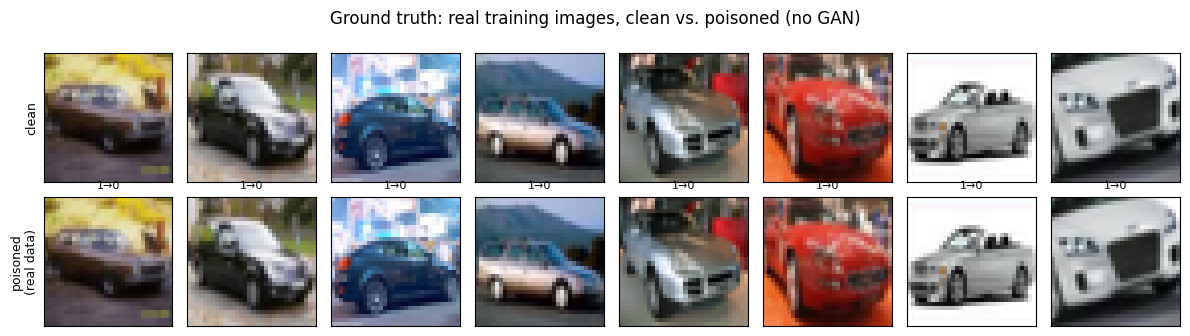

In [7]:
# Ground-truth check: real training images before/after poisoning, straight from apply_trigger()
# (Section 3) with NO generator involved. Compare this against the GAN's generated-sample panel in
# Section 8 — if the trigger isn't visible here either, the bug is in poisoning/CONFIG, not
# the GAN; if it IS visible here but not in Section 8's panel, the bug is GAN-side.
poison_sample_ids = list(loaders["poison_indices"])[:8]
if len(poison_sample_ids) == 0:
    print("No poisoned samples were selected — check CONFIG['poison_rate'] / 'source_label'.")
else:
    fig, axes = plt.subplots(2, len(poison_sample_ids), figsize=(1.5 * len(poison_sample_ids), 3.4))
    if len(poison_sample_ids) == 1:
        axes = axes.reshape(2, 1)
    for col, real_idx in enumerate(poison_sample_ids):
        x_clean, y_orig = train_ds[real_idx]  # raw [0,1], unpoisoned
        x_poison = apply_trigger(x_clean, CONFIG).clamp(0, 1)

        for row, img in enumerate([x_clean, x_poison]):
            disp = img.permute(1, 2, 0).squeeze(-1) if img.shape[0] == 1 else img.permute(1, 2, 0)
            axes[row, col].imshow(disp, cmap="gray" if CONFIG["channels"] == 1 else None)
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
        axes[1, col].set_title(f"{y_orig}\u2192{CONFIG['target_label']}", fontsize=8)

    axes[0, 0].set_ylabel("clean", fontsize=9)
    axes[1, 0].set_ylabel("poisoned\n(real data)", fontsize=9)
    plt.suptitle("Ground truth: real training images, clean vs. poisoned (no GAN)")
    plt.tight_layout()
    plt.show()


## 5. Classifier

A deliberately simple CNN, per the paper ("the model used in the experiment is relatively
simple" — Section 6.4), reused unchanged across MNIST-family datasets and CIFAR-10 (paper:
"the same network structure as that on the MNIST dataset" — Section 6.3). `conv2`'s output
is also where the data-free generator's activation loss (Section 7 below) taps in.


In [8]:
class ConvTrunk(nn.Module):
    # Shared feature-extractor architecture (paper Table 1's discriminator column: Conv/LReLU/
    # Dropout -> Conv/BN/LReLU -> Conv/BN/LReLU -> Global Average Pooling -> 256). The
    # classifier (backdoored model / teacher) and the GAN discriminator (Section 8) both use
    # this exact trunk -- same layer count, same shapes -- per the paper's "the global model
    # and the discriminator model will adopt a network structure with different outputs but
    # the same number of layers to ensure the discriminator model will be updated synchronously
    # through the global model parameters" (Sec. 5.2). That synchronization is the paper's
    # actual backdoor-injection mechanism for the GAN; see Section 8.
    def __init__(self, channels, input_size):
        super().__init__()
        if input_size == 28:
            conv_cfg = [(channels, 64, 4, 2, 1), (64, 128, 4, 2, 1), (128, 256, 3, 2, 1)]
        elif input_size == 32:
            conv_cfg = [(channels, 64, 4, 2, 1), (64, 128, 4, 2, 1), (128, 256, 4, 2, 1)]
        else:
            raise ValueError(f"Unsupported input_size {input_size}")
        layers = []
        for idx, (cin, cout, k, s, p) in enumerate(conv_cfg):
            layers.append(nn.Conv2d(cin, cout, k, s, p))
            if idx == 0:
                layers += [nn.LeakyReLU(0.2, inplace=True), nn.Dropout(0.25)]
            else:
                layers += [nn.BatchNorm2d(cout), nn.LeakyReLU(0.2, inplace=True)]
        self.conv = nn.Sequential(*layers)
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        return self.gap(self.conv(x)).flatten(1)  # (B, 256)


class Classifier(nn.Module):
    def __init__(self, channels, num_classes, input_size):
        super().__init__()
        self.trunk = ConvTrunk(channels, input_size)
        self.head = nn.Linear(256, num_classes)

    def forward(self, x):
        return self.head(self.trunk(x))


def train_classifier(model, loader, epochs, lr, tag="", capture_trunk_every=None):
    # capture_trunk_every: if set, deep-copies model.trunk.state_dict() after every N epochs
    # (always including the final epoch) and returns them alongside the model. Used to build
    # `backdoored_trunk_checkpoints` (Section 6) -- a stand-in for "the global model of the
    # following [federated] rounds" that the GAN discriminator re-syncs from (Section 8).
    model.to(device).train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    trunk_checkpoints = []
    for epoch in range(epochs):
        total, n = 0.0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
            n += x.size(0)
        print(f"[{tag}] epoch {epoch + 1}/{epochs} loss={total / n:.4f}")
        if capture_trunk_every and (epoch + 1) % capture_trunk_every == 0:
            trunk_checkpoints.append(copy.deepcopy(model.trunk.state_dict()))
    if capture_trunk_every and not trunk_checkpoints:
        trunk_checkpoints.append(copy.deepcopy(model.trunk.state_dict()))
    return model, trunk_checkpoints


@torch.no_grad()
def evaluate_acc(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return correct / total


## 6. Train the backdoored model ("Before ADFL")

Trained only on the pool (the server's clean holdout is *not* used here — it is only
available to ADFL's defense side, mirroring the paper's threat model).


In [9]:
set_seed(CONFIG["seed"])  # reseed here: Section 6 must be reproducible on its own, not just
                          # depend on how much RNG state earlier cells in this Colab session
                          # happened to consume since the CONFIG cell's one-time set_seed call.
backdoored_model = Classifier(CONFIG["channels"], CONFIG["num_classes"], CONFIG["input_size"])
backdoored_model, backdoored_trunk_checkpoints = train_classifier(
    backdoored_model, loaders["train_pool"], CONFIG["clf_epochs"], CONFIG["clf_lr"],
    tag="backdoored", capture_trunk_every=1)
# `backdoored_trunk_checkpoints` -- one snapshot of the trunk's weights per training epoch --
# stands in for "the global model of the following [federated] rounds" (paper Sec. 5.2) that
# the GAN's discriminator gets periodically re-synced from in Section 8. Centralizing away
# FedAvg removes the per-round model churn the paper's mechanism relies on; rotating over this
# model's own training trajectory is the cheapest faithful substitute (agreed with the user
# over reintroducing FL) -- see the Notes cell.

acc_before = evaluate_acc(backdoored_model, loaders["clean_test"])
asr_before = evaluate_acc(backdoored_model, loaders["asr_test"])
print(f"\nBefore ADFL — ACC: {acc_before * 100:.2f}%  ASR: {asr_before * 100:.2f}%")


[backdoored] epoch 1/30 loss=1.6598
[backdoored] epoch 2/30 loss=1.4332
[backdoored] epoch 3/30 loss=1.3322
[backdoored] epoch 4/30 loss=1.2627
[backdoored] epoch 5/30 loss=1.2157
[backdoored] epoch 6/30 loss=1.1693
[backdoored] epoch 7/30 loss=1.1395
[backdoored] epoch 8/30 loss=1.1074
[backdoored] epoch 9/30 loss=1.0833
[backdoored] epoch 10/30 loss=1.0596
[backdoored] epoch 11/30 loss=1.0385
[backdoored] epoch 12/30 loss=1.0225
[backdoored] epoch 13/30 loss=1.0045
[backdoored] epoch 14/30 loss=0.9880
[backdoored] epoch 15/30 loss=0.9785
[backdoored] epoch 16/30 loss=0.9646
[backdoored] epoch 17/30 loss=0.9501
[backdoored] epoch 18/30 loss=0.9374
[backdoored] epoch 19/30 loss=0.9265
[backdoored] epoch 20/30 loss=0.9175
[backdoored] epoch 21/30 loss=0.9037
[backdoored] epoch 22/30 loss=0.8943
[backdoored] epoch 23/30 loss=0.8884
[backdoored] epoch 24/30 loss=0.8773
[backdoored] epoch 25/30 loss=0.8647
[backdoored] epoch 26/30 loss=0.8593
[backdoored] epoch 27/30 loss=0.8503
[backdoore

## 7. Train the clean / teacher model

Trained only on the server's small clean holdout. This model plays two roles in ADFL: it
**relabels** the generator's fake samples, and it is the **teacher** in the distillation
step.


In [10]:
set_seed(CONFIG["seed"] + 1)  # reseed here too, for the same reason as Section 6 -- offset
                              # by 1 so the teacher doesn't get identical init to the backdoored
                              # model, while still being reproducible run to run.
clean_model = Classifier(CONFIG["channels"], CONFIG["num_classes"], CONFIG["input_size"])
clean_model, _ = train_classifier(clean_model, loaders["clean_holdout"], CONFIG["teacher_epochs"], CONFIG["teacher_lr"], tag="teacher")

teacher_acc = evaluate_acc(clean_model, loaders["clean_test"])
print(f"\nTeacher (clean-only) ACC: {teacher_acc * 100:.2f}%")


[teacher] epoch 1/20 loss=2.1438
[teacher] epoch 2/20 loss=1.9638
[teacher] epoch 3/20 loss=1.8995
[teacher] epoch 4/20 loss=1.8486
[teacher] epoch 5/20 loss=1.7893
[teacher] epoch 6/20 loss=1.7621
[teacher] epoch 7/20 loss=1.7173
[teacher] epoch 8/20 loss=1.6807
[teacher] epoch 9/20 loss=1.6743
[teacher] epoch 10/20 loss=1.6214
[teacher] epoch 11/20 loss=1.5866
[teacher] epoch 12/20 loss=1.5494
[teacher] epoch 13/20 loss=1.5320
[teacher] epoch 14/20 loss=1.5699
[teacher] epoch 15/20 loss=1.5078
[teacher] epoch 16/20 loss=1.5020
[teacher] epoch 17/20 loss=1.5023
[teacher] epoch 18/20 loss=1.4685
[teacher] epoch 19/20 loss=1.4577
[teacher] epoch 20/20 loss=1.4462

Teacher (clean-only) ACC: 39.13%


## 8. ADFL step 1 — distillation-data generator (paper Eq. 2/3, discriminator re-synced from the backdoored model)

DCGAN-style generator/discriminator, matching the paper's stated architecture for the 28x28
case (FC → `7x7x256` → ConvT/BN/LReLU → `7x7x128` → ConvT/BN/LReLU → `14x14x64` →
ConvT/Tanh → `28x28xC`; discriminator mirrors the classifier's trunk — Conv/BN/LReLU/Dropout,
`LReLU, DP, BN` per the paper's Table 1 legend — plus a 1-dim head); a straightforward 32x32
extension is used for CIFAR-10/CelebA.

**The generator's loss is exactly the paper's Eq. 2/3 — vanilla GAN, nothing else.** Six
earlier rounds of this notebook added a "backdoor-guidance" cross-entropy term pushing
generated samples toward the frozen backdoored model's `target_label`, plus TV penalties and
expectation-over-transformations robustness tricks on top of it, chasing a visible trigger
that never appeared. Recovering Algorithm 1 and Eq. 2/3 from the paper's PDF (the OCR text
this notebook was originally built from dropped both float boxes) shows that loss never
existed in the paper — it was this notebook's own invention, and it is exactly the kind of
objective that lets a generator converge onto a cheap adversarial shortcut instead of the real
trigger. It has been deleted rather than tuned further.

**The paper's actual mechanism for injecting the backdoor into the GAN** is architectural, not
a loss term (Sec. 5.2, Algorithm 1's `D(x) ← G̃t`): *"the global model and the discriminator
model will adopt a network structure with different outputs but the same number of layers to
ensure the discriminator model will be updated synchronously through the global model
parameters"* — and later, explicitly causal: *"update the discriminator with the global model
of the following rounds ... to ensure that the backdoor samples can be generated."* Concretely:
- `D`'s trunk is the **same architecture** as the classifier's (`ConvTrunk`, Section 5), so its
  weights can be copied in directly. Its head (`Linear(256, 1)`) is separate and trained
  normally.
- `D`'s trunk is **initialized from the backdoored model's first checkpoint**, then
  **periodically re-synced** from later checkpoints (`d_resync_every` GAN epochs) — the
  centralized substitute for the paper's per-communication-round global-model churn (agreed
  with the user over reintroducing FedAvg; see the Notes cell).
- The real branch of `D`'s adversarial loss (Eq. 3) is trained against the server's real clean
  holdout, matching Algorithm 1's `Bgan <- split(D_clean, ...)`.
- The generator is **unconditional** (`z` only, Table 1's stated input) — no class label, no
  one-hot. Labels for generated samples come later, in Section 9, from the teacher.


In [11]:
class Generator(nn.Module):
    def __init__(self, latent_dim, channels, output_size):
        super().__init__()
        if output_size == 28:
            self.init_size = 7
            deconv_cfg = [(256, 128, 3, 1, 1), (128, 64, 4, 2, 1), (64, channels, 4, 2, 1)]
        elif output_size == 32:
            self.init_size = 4
            deconv_cfg = [(256, 128, 4, 2, 1), (128, 64, 4, 2, 1), (64, channels, 4, 2, 1)]
        else:
            raise ValueError(f"Unsupported output_size {output_size}")

        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 256 * self.init_size * self.init_size),
            nn.BatchNorm1d(256 * self.init_size * self.init_size),
            nn.LeakyReLU(0.2, inplace=True),
        )
        layers = []
        for idx, (cin, cout, k, s, p) in enumerate(deconv_cfg):
            layers.append(nn.ConvTranspose2d(cin, cout, k, s, p))
            if idx < len(deconv_cfg) - 1:
                layers += [nn.BatchNorm2d(cout), nn.LeakyReLU(0.2, inplace=True)]
            else:
                layers.append(nn.Tanh())
        self.deconv = nn.Sequential(*layers)

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.size(0), 256, self.init_size, self.init_size)
        return self.deconv(out)


class Discriminator(nn.Module):
    # Same trunk as the classifier (ConvTrunk, Section 5) so its weights can be copied directly
    # from a backdoored-model checkpoint -- see sync_discriminator_trunk() and the Section 8
    # markdown above.
    def __init__(self, channels, input_size):
        super().__init__()
        self.trunk = ConvTrunk(channels, input_size)
        self.head = nn.Linear(256, 1)

    def forward(self, x):
        return self.head(self.trunk(x))


def sync_discriminator_trunk(D, trunk_state_dict, freeze=False):
    # freeze (Section 13c H2 probe): when True, the trunk is held fixed exactly as re-synced --
    # requires_grad=False so opt_d (built over D.head only in that case, see train_generator)
    # never touches it, and eval() mode so its BatchNorm running stats also stay frozen at the
    # backdoored checkpoint's values instead of drifting toward GAN-batch statistics. Re-applied
    # after every sync since load_state_dict doesn't touch requires_grad/train-mode flags.
    D.trunk.load_state_dict(trunk_state_dict)
    for p in D.trunk.parameters():
        p.requires_grad_(not freeze)
    D.trunk.train(not freeze)


def train_generator(target_checkpoints, cfg, real_loader):
    # target_checkpoints: trunk state_dicts sampled across the backdoored model's own training
    # trajectory (train_classifier's capture_trunk_every). D's trunk is initialized from the
    # first checkpoint and periodically re-synced from later ones -- Algorithm 1's
    # `D(x) <- G~t` plus the paper's "global model of the FOLLOWING rounds" (Sec. 5.2),
    # substituting this model's own training trajectory for federated communication rounds
    # (see Notes cell). The loss is exactly Eq. 2 (G) / Eq. 3 (D) -- no other term.
    #
    # cfg["d_trunk_frozen"] (Section 13c H2 probe, default False): when True, D's trunk is
    # updated only by the re-syncs above and never by opt_d/backprop -- isolating whether the
    # ~gan_steps_per_epoch * d_resync_every free gradient steps the trunk otherwise takes
    # between re-syncs wash out whatever trigger signal the backdoored checkpoint carried in.
    G = Generator(cfg["latent_dim"], cfg["channels"], cfg["input_size"]).to(device)
    D = Discriminator(cfg["channels"], cfg["input_size"]).to(device)
    d_trunk_frozen = cfg.get("d_trunk_frozen", False)
    sync_discriminator_trunk(D, target_checkpoints[0], freeze=d_trunk_frozen)
    opt_g = torch.optim.Adam(G.parameters(), lr=cfg["gan_lr"], betas=(0.5, 0.999))
    d_params = D.head.parameters() if d_trunk_frozen else D.parameters()
    opt_d = torch.optim.Adam(d_params, lr=cfg["gan_lr"], betas=(0.5, 0.999))
    bce = nn.BCEWithLogitsLoss()

    snapshot_every = cfg.get("gan_snapshot_every", max(1, cfg["gan_epochs"] // 6))
    snapshots = []

    def capture_snapshot(epoch_label):
        G.eval()
        with torch.no_grad():
            z = torch.randn(8, cfg["latent_dim"], device=device)
            imgs = (G(z).cpu() * 0.5 + 0.5).clamp(0, 1)
        G.train()
        snapshots.append((epoch_label, imgs))

    real_iter = iter(real_loader)

    def next_real_batch():
        nonlocal real_iter
        try:
            x, _ = next(real_iter)
        except StopIteration:
            real_iter = iter(real_loader)
            x, _ = next(real_iter)
        return x.to(device)

    capture_snapshot(0)  # pre-training baseline (pure noise)
    resync_pointer = 0

    for epoch in range(cfg["gan_epochs"]):
        if cfg["d_resync_every"] and epoch > 0 and epoch % cfg["d_resync_every"] == 0:
            resync_pointer = (resync_pointer + 1) % len(target_checkpoints)
            sync_discriminator_trunk(D, target_checkpoints[resync_pointer], freeze=d_trunk_frozen)

        for _ in range(cfg["gan_steps_per_epoch"]):
            # --- Discriminator step (Eq. 3): real (clean holdout) vs. fake ---
            real_x = next_real_batch()
            b = real_x.size(0)

            z = torch.randn(b, cfg["latent_dim"], device=device)
            fake_x = G(z).detach()

            d_real = D(real_x)
            d_fake = D(fake_x)
            d_loss = bce(d_real, torch.ones_like(d_real)) + bce(d_fake, torch.zeros_like(d_fake))
            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # --- Generator step (Eq. 2): maximize log D(G(z)) ---
            z = torch.randn(b, cfg["latent_dim"], device=device)
            fake_x = G(z)
            g_loss = bce(D(fake_x), torch.ones_like(d_fake))
            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

        print(f"[GAN] epoch {epoch + 1}/{cfg['gan_epochs']} "
              f"d_loss={d_loss.item():.4f} g_loss={g_loss.item():.4f}")

        if (epoch + 1) % snapshot_every == 0 or epoch == cfg["gan_epochs"] - 1:
            capture_snapshot(epoch + 1)

    return G, snapshots


generator, gan_snapshots = train_generator(backdoored_trunk_checkpoints, CONFIG, loaders["clean_holdout"])

[GAN] epoch 1/30 d_loss=1.2858 g_loss=0.7607
[GAN] epoch 2/30 d_loss=1.1795 g_loss=0.8332
[GAN] epoch 3/30 d_loss=1.2940 g_loss=0.7934
[GAN] epoch 4/30 d_loss=1.1139 g_loss=0.8998
[GAN] epoch 5/30 d_loss=1.1275 g_loss=0.8667
[GAN] epoch 6/30 d_loss=1.3496 g_loss=0.7210
[GAN] epoch 7/30 d_loss=1.3261 g_loss=0.7305
[GAN] epoch 8/30 d_loss=1.1093 g_loss=0.8677
[GAN] epoch 9/30 d_loss=1.2760 g_loss=0.7890
[GAN] epoch 10/30 d_loss=1.2361 g_loss=0.8448
[GAN] epoch 11/30 d_loss=1.3597 g_loss=0.7137
[GAN] epoch 12/30 d_loss=1.3370 g_loss=0.7269
[GAN] epoch 13/30 d_loss=1.3098 g_loss=0.7358
[GAN] epoch 14/30 d_loss=1.2886 g_loss=0.7552
[GAN] epoch 15/30 d_loss=1.2885 g_loss=0.7596
[GAN] epoch 16/30 d_loss=1.3669 g_loss=0.7144
[GAN] epoch 17/30 d_loss=1.3417 g_loss=0.7132
[GAN] epoch 18/30 d_loss=1.3181 g_loss=0.7333
[GAN] epoch 19/30 d_loss=1.2905 g_loss=0.7447
[GAN] epoch 20/30 d_loss=1.3043 g_loss=0.7507
[GAN] epoch 21/30 d_loss=1.3708 g_loss=0.7049
[GAN] epoch 22/30 d_loss=1.3559 g_loss=0.71

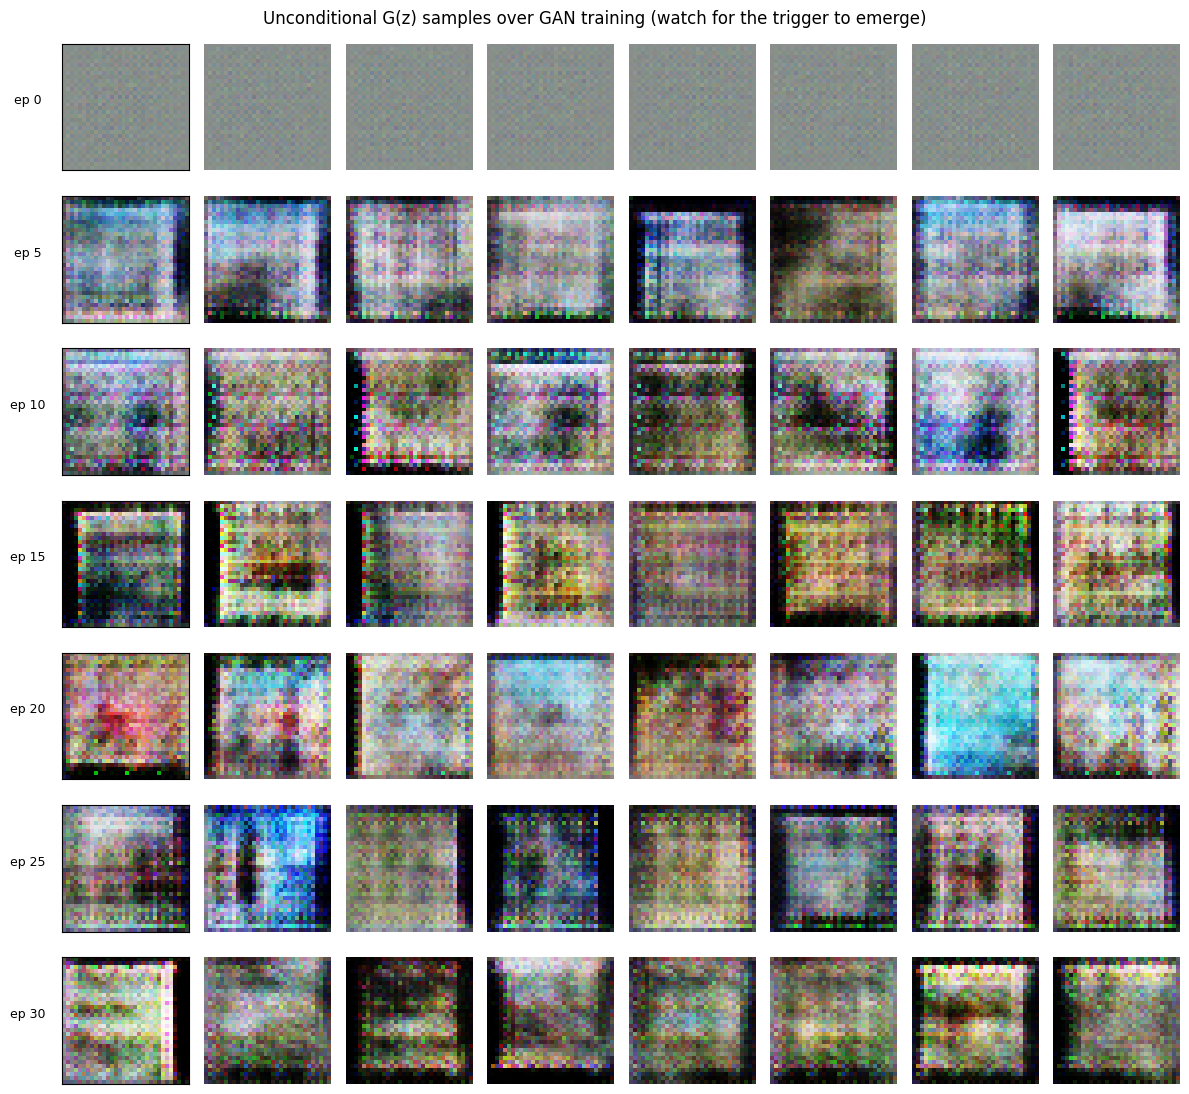

In [12]:
# Training-progress panel: unconditional G(z) samples captured every `gan_snapshot_every`
# epochs (see train_generator). Watch the trigger emerge (or fail to) across the run -- the
# paper reports the watermark trigger only becomes recognizable after ~100 rounds and the
# pixel-block trigger has "noise point[s] inside the square that will disappear after certain
# rounds" (Sec. 6.3, Fig. 6), so an early row with no trigger is expected, not a bug.
if gan_snapshots:
    n_rows = len(gan_snapshots)
    fig, axes = plt.subplots(n_rows, 8, figsize=(12, 1.6 * n_rows))
    if n_rows == 1:
        axes = axes[None, :]
    for row, (epoch_label, imgs) in enumerate(gan_snapshots):
        for col, img in enumerate(imgs):
            img_ = img.permute(1, 2, 0).squeeze(-1) if img.shape[0] == 1 else img.permute(1, 2, 0)
            axes[row, col].imshow(img_, cmap="gray" if CONFIG["channels"] == 1 else None)
            axes[row, col].axis("off")
        axes[row, 0].axis("on")
        axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
        axes[row, 0].set_ylabel(f"ep {epoch_label}", rotation=0, labelpad=25, fontsize=9)
    plt.suptitle("Unconditional G(z) samples over GAN training (watch for the trigger to emerge)")
    plt.tight_layout()
    plt.show()


## 9. ADFL step 2 — relabel with the clean/teacher model

The generated samples are unlabeled (`G(z)` takes only noise, Section 8); the clean/teacher
model assigns pseudo-labels, forming the distillation dataset (paper: 10,000 samples) — exactly
Algorithm 1's `y = f(Gclean, x_fake)`.

**Instrument (Phase 0 of the replication plan): backdoor-activation rate.** The paper's Fig. 7
analogue compares teacher labels against a *known* ground truth for the generated samples,
and reports the fraction of generated images that carry the trigger ("about 50% ... at 1%
clean data ... about 85% ... at 5%", Sec. 6.3). Since this notebook doesn't have ground-truth
labels for generated images, the closest available proxy is: of the samples the *backdoored*
model classifies as `target_label`, what fraction does the *teacher* disagree with? A high
rate means the generator is reproducing trigger-like features the backdoored model reacts to
but the (unaffected) teacher doesn't — exactly the correction signal ADFL's knowledge
distillation step needs. A rate near zero means the generator hasn't learned to reproduce the
backdoor at all, regardless of how the generated images look.


In [13]:
@torch.no_grad()
def generate_and_relabel(generator, teacher, n, cfg, backdoored_model=None, batch_size=500):
    # cfg["distill_conf_floor"] (NOT in the paper, default 0.0 = off -- see CONFIG comment):
    # discards generated samples whose teacher-relabel confidence falls below this floor,
    # instead of keeping every generated sample the way the original (pre-2026-09-03) version
    # did. Over-generates in batches until `n` samples clear the floor (or `max_batches` is hit,
    # a safety cap against an unreachable floor looping forever) rather than down-weighting
    # low-confidence samples' loss, so KD's math -- validated correct by Section 13a's row C --
    # stays untouched; only WHICH samples reach it changes. At the default 0.0, every generated
    # sample clears it (softmax max-prob is always > 0), so this reproduces the original
    # unfiltered behavior exactly, batch-for-batch.
    generator.eval()
    teacher.eval()
    if backdoored_model is not None:
        backdoored_model.eval()
    conf_floor = cfg.get("distill_conf_floor", 0.0)
    max_batches = max(50, 10 * -(-n // batch_size))
    xs, ys, confs = [], [], []
    bd_target_count, bd_target_teacher_disagrees = 0, 0
    n_generated_total = 0
    kept = 0
    batches_run = 0
    while kept < n and batches_run < max_batches:
        b = min(batch_size, n - kept)
        z = torch.randn(b, cfg["latent_dim"], device=device)
        x = generator(z)
        logits = teacher(x)
        probs = F.softmax(logits, dim=1)
        conf, y = probs.max(dim=1)
        n_generated_total += b
        if backdoored_model is not None:
            bd_y = backdoored_model(x).argmax(1)
            is_bd_target = bd_y == cfg["target_label"]
            bd_target_count += is_bd_target.sum().item()
            bd_target_teacher_disagrees += (is_bd_target & (y != cfg["target_label"])).sum().item()
        keep_mask = conf >= conf_floor
        xs.append(x[keep_mask].cpu())
        ys.append(y[keep_mask].cpu())
        confs.append(conf[keep_mask].cpu())
        kept += keep_mask.sum().item()
        batches_run += 1
    if kept < n:
        print(f"WARNING: distill_conf_floor={conf_floor} too strict -- only {kept}/{n} samples "
              f"cleared it after generating {n_generated_total} candidates over "
              f"{batches_run} batches; using what was found.")
    xs = torch.cat(xs) if xs else torch.empty(0, cfg["channels"], cfg["input_size"], cfg["input_size"])
    ys = torch.cat(ys) if ys else torch.empty(0, dtype=torch.long)
    confs = torch.cat(confs) if confs else torch.empty(0)
    diag = {"n_generated": n_generated_total, "n_kept": kept}
    if backdoored_model is not None:
        diag["backdoor_activation_rate"] = bd_target_count / n_generated_total
        diag["backdoor_activation_rate_disagreeing_teacher"] = bd_target_teacher_disagrees / n_generated_total
    return xs, ys, confs, diag


def sample_clean_mix(clean_holdout_ds, n, seed):
    # Real, untriggered, TRUE-labeled samples drawn (with replacement) from the server's clean
    # holdout -- mixed into the distillation set alongside the synthetic/relabeled ones. See
    # CONFIG["distill_clean_mix_frac"] for why this exists.
    idx_pool = list(range(len(clean_holdout_ds)))
    if n <= 0 or not idx_pool:
        return torch.empty(0), torch.empty(0, dtype=torch.long)
    rng = random.Random(seed)
    xs, ys = [], []
    for _ in range(n):
        i = idx_pool[rng.randrange(len(idx_pool))]
        x, y = clean_holdout_ds[i]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs), torch.tensor(ys, dtype=torch.long)


def n_synth_distill(cfg):
    return cfg["n_distill"] - int(cfg["n_distill"] * cfg["distill_clean_mix_frac"])


def build_distill_loader(gen_x, gen_y, clean_holdout_ds, cfg, seed):
    # Combines synthetic/relabeled distillation samples (already sized to n_synth_distill(cfg)
    # by the caller) with a real, untriggered, true-labeled slice of the clean holdout sized to
    # the remainder -- see sample_clean_mix and CONFIG["distill_clean_mix_frac"].
    n_mix = cfg["n_distill"] - gen_x.shape[0]
    mix_x, mix_y = sample_clean_mix(clean_holdout_ds, n_mix, seed)
    x = torch.cat([gen_x, mix_x]) if n_mix > 0 else gen_x
    y = torch.cat([gen_y, mix_y]) if n_mix > 0 else gen_y
    return DataLoader(TensorDataset(x, y), batch_size=cfg["batch_size"], shuffle=True)


distill_x, distill_y, distill_conf, distill_diag = generate_and_relabel(
    generator, clean_model, n_synth_distill(CONFIG), CONFIG, backdoored_model=backdoored_model)
n_generated = distill_diag["n_generated"]
n_dropped = n_generated - distill_x.shape[0]
print(f"Distillation set: {distill_x.shape[0]} synthetic + "
      f"{CONFIG['n_distill'] - distill_x.shape[0]} real-untriggered-clean samples "
      f"({n_dropped}/{n_generated} generated candidates dropped by "
      f"distill_conf_floor={CONFIG['distill_conf_floor']}), "
      f"mean teacher confidence (synthetic part, post-filter)={distill_conf.mean().item():.3f}, "
      f"label distribution (synthetic part)={torch.bincount(distill_y, minlength=CONFIG['num_classes']).tolist()}")
if distill_diag:
    print(f"Backdoor-activation rate (Section 9 instrument, over all {n_generated} generated "
          f"candidates pre-filter): the BACKDOORED model calls "
          f"{distill_diag['backdoor_activation_rate'] * 100:.1f}% of generated samples "
          f"class {CONFIG['target_label']}, and the TEACHER disagrees on "
          f"{distill_diag['backdoor_activation_rate_disagreeing_teacher'] * 100:.1f}% of ALL "
          "generated samples (paper's Fig. 7 analogue: ~50% at 1% clean data, ~85% at 5%). "
          "Near-zero means the generator has not learned to reproduce the trigger.")

distill_loader = build_distill_loader(
    distill_x, distill_y, loaders["clean_holdout"].dataset, CONFIG, CONFIG["seed"] + 2000)

Distillation set: 8000 synthetic + 2000 real-untriggered-clean samples (18595/26595 generated candidates dropped by distill_conf_floor=0.5), mean teacher confidence (synthetic part, post-filter)=0.639, label distribution (synthetic part)=[254, 1822, 0, 0, 26, 8, 3760, 149, 392, 1589]
Backdoor-activation rate (Section 9 instrument, over all 26595 generated candidates pre-filter): the BACKDOORED model calls 0.1% of generated samples class 0, and the TEACHER disagrees on 0.1% of ALL generated samples (paper's Fig. 7 analogue: ~50% at 1% clean data, ~85% at 5%). Near-zero means the generator has not learned to reproduce the trigger.


## 10. ADFL step 3 — knowledge distillation (purification)

Teacher = clean model, student = a copy of the backdoored model, per the paper's Eq. 4-7:

```
q_i = softmax(z_i / T)                            (Eq. 4, T=1 recovers standard softmax)
L_soft = cross-entropy(teacher's T-softened output, student's T-softened output)   (Eq. 5)
L_hard = cross-entropy(student's T=1 output, ground-truth label)                   (Eq. 6)
L = L_hard + alpha * L_soft                                                        (Eq. 7)
```

Two details the earlier version of this notebook got wrong, both directly from the paper's
text (Sec. 5.4, `..._plain.txt:51`, cross-checked against the PDF's equations):
- **`L_soft` is a plain cross-entropy between softened teacher/student outputs, not a
  KL-divergence**, and it is **not** rescaled by `T²` (the classic Hinton et al. trick, which
  this paper's equations do not use).
- **The hard-label term's weight is fixed at 1**; only the soft term is scaled, by `alpha`.
  Neither `T` nor `alpha` is given a numeric value anywhere in the paper — both are swept in
  Section 14.

`L_hard`'s "ground truth" `c_j` (Eq. 6) can only be the teacher's own relabel `y` from Section
9 — nothing else labels the generator's output. The paper never states this explicitly, but no
other reading is possible given Algorithm 1.


In [14]:
def knowledge_distill(student, teacher, loader, cfg):
    student.to(device).train()
    teacher.to(device).eval()
    T = cfg["kd_temperature"]
    alpha = cfg["kd_alpha"]
    opt = torch.optim.Adam(student.parameters(), lr=cfg["kd_lr"])
    for epoch in range(cfg["kd_epochs"]):
        total, n = 0.0, 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.no_grad():
                t_soft = F.softmax(teacher(x) / T, dim=1)
            s_logits = student(x)
            s_log_soft = F.log_softmax(s_logits / T, dim=1)
            # Eq. 5: cross-entropy between the teacher's and student's T-softened outputs --
            # NOT KL-divergence, and NOT rescaled by T^2 (see Section 10 markdown).
            soft_loss = -(t_soft * s_log_soft).sum(dim=1).mean()
            # Eq. 6: cross-entropy against the ground-truth label y (the teacher's own relabel
            # for generated data -- see Section 10 markdown).
            hard_loss = F.cross_entropy(s_logits, y)
            loss = hard_loss + alpha * soft_loss  # Eq. 7
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
            n += x.size(0)
        print(f"[KD] epoch {epoch + 1}/{cfg['kd_epochs']} loss={total / n:.4f}")
    return student


purified_model = copy.deepcopy(backdoored_model)
knowledge_distill(purified_model, clean_model, distill_loader, CONFIG)

acc_after = evaluate_acc(purified_model, loaders["clean_test"])
asr_after = evaluate_acc(purified_model, loaders["asr_test"])
print(f"\nAfter ADFL — ACC: {acc_after * 100:.2f}%  ASR: {asr_after * 100:.2f}%")


[KD] epoch 1/20 loss=3.0838
[KD] epoch 2/20 loss=2.6827
[KD] epoch 3/20 loss=2.6218
[KD] epoch 4/20 loss=2.5974
[KD] epoch 5/20 loss=2.5674
[KD] epoch 6/20 loss=2.5498
[KD] epoch 7/20 loss=2.5329
[KD] epoch 8/20 loss=2.5268
[KD] epoch 9/20 loss=2.5078
[KD] epoch 10/20 loss=2.5030
[KD] epoch 11/20 loss=2.4940
[KD] epoch 12/20 loss=2.4859
[KD] epoch 13/20 loss=2.4786
[KD] epoch 14/20 loss=2.4729
[KD] epoch 15/20 loss=2.4662
[KD] epoch 16/20 loss=2.4635
[KD] epoch 17/20 loss=2.4549
[KD] epoch 18/20 loss=2.4505
[KD] epoch 19/20 loss=2.4488
[KD] epoch 20/20 loss=2.4448

After ADFL — ACC: 69.52%  ASR: 5.41%


## 11. Evaluation — before/after summary and confusion matrices

Reproduces the paper's core claim (Section 6.4): ADFL should sharply cut ASR while keeping
ACC close to (or above) its pre-defense level.


In [15]:
print(f"{'':10s}{'ACC':>10s}{'ASR':>10s}")
print(f"{'Before':10s}{acc_before * 100:9.2f}%{asr_before * 100:9.2f}%")
print(f"{'After':10s}{acc_after * 100:9.2f}%{asr_after * 100:9.2f}%")


                 ACC       ASR
Before        71.70%    15.36%
After         69.52%     5.41%


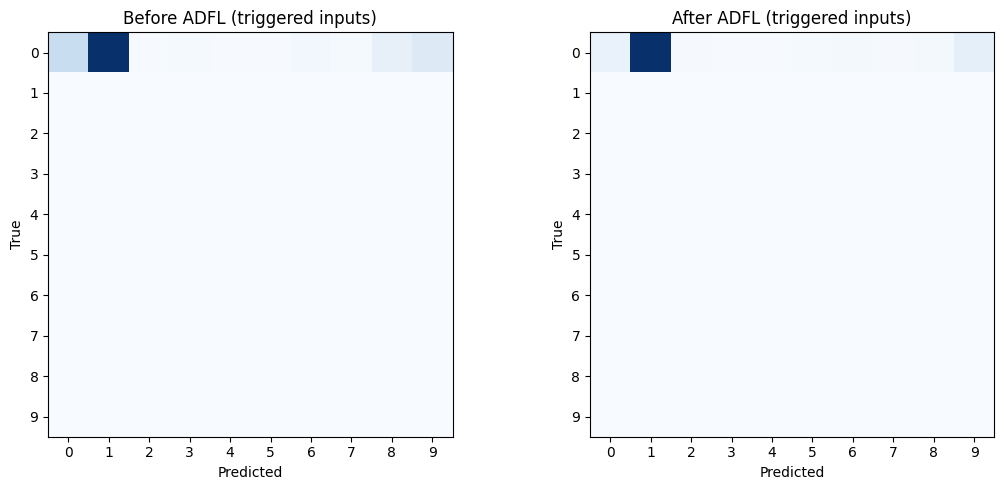

Rows are true labels of triggered test samples; a healthy defense moves mass off the target-label column (column 0) and back onto the diagonal.


In [16]:
@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        pred = model(x).argmax(1).cpu()
        y_true.append(y)
        y_pred.append(pred)
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()


yt_before, yp_before = collect_preds(backdoored_model, loaders["asr_test"])
yt_after, yp_after = collect_preds(purified_model, loaders["asr_test"])

labels = list(range(CONFIG["num_classes"]))
cm_before = confusion_matrix(yt_before, yp_before, labels=labels)
cm_after = confusion_matrix(yt_after, yp_after, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, cm, title in zip(axes, [cm_before, cm_after], ["Before ADFL (triggered inputs)", "After ADFL (triggered inputs)"]):
    im = ax.imshow(cm, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(labels)
    ax.set_yticks(labels)
plt.tight_layout()
plt.show()
print("Rows are true labels of triggered test samples; a healthy defense moves mass off the "
      f"target-label column (column {CONFIG['target_label']}) and back onto the diagonal.")


## 12. Experiment harness — `pipeline()`, `run_experiment()`, `assert_sweep_override()`

Single execution path for every multi-run result below (diagnostics, calibration, and the
Section 14 sweeps): one call to `pipeline()` per (config, seed), with `run_experiment()`
wrapping it over multiple seeds for a mean +/- std. `assert_sweep_override()` guards every
sweep against silently changing more than the variable it claims to sweep -- the exact bug
that made this notebook's main-run and sweep-point numbers incomparable in earlier rounds
(see the Notes cell).


In [ ]:
def pipeline(cfg, train_ds, test_ds, verbose=False):
    cfg = dict(cfg)  # shallow copy; safe since we only overwrite top-level scalar keys
    set_seed(cfg["seed"])
    loaders = build_loaders(cfg, train_ds, test_ds)

    bm = Classifier(cfg["channels"], cfg["num_classes"], cfg["input_size"])
    bm, bm_checkpoints = train_classifier(
        bm, loaders["train_pool"], cfg["clf_epochs"], cfg["clf_lr"],
        tag="backdoored" if verbose else "", capture_trunk_every=1)

    cm_ = Classifier(cfg["channels"], cfg["num_classes"], cfg["input_size"])
    cm_, _ = train_classifier(cm_, loaders["clean_holdout"], cfg["teacher_epochs"], cfg["teacher_lr"],
                               tag="teacher" if verbose else "")

    gen, _ = train_generator(bm_checkpoints, cfg, loaders["clean_holdout"])
    dx, dy, _, diag = generate_and_relabel(gen, cm_, n_synth_distill(cfg), cfg, backdoored_model=bm)
    dloader = build_distill_loader(dx, dy, loaders["clean_holdout"].dataset, cfg, cfg["seed"] + 2000)

    pm = copy.deepcopy(bm)
    knowledge_distill(pm, cm_, dloader, cfg)

    return {
        "acc_before": evaluate_acc(bm, loaders["clean_test"]),
        "asr_before": evaluate_acc(bm, loaders["asr_test"]),
        "acc_after": evaluate_acc(pm, loaders["clean_test"]),
        "asr_after": evaluate_acc(pm, loaders["asr_test"]),
        "teacher_acc": evaluate_acc(cm_, loaders["clean_test"]),
        "backdoor_activation_rate": diag.get("backdoor_activation_rate"),
        "backdoored_model": bm,
        "clean_model": cm_,
        "generator": gen,
        "purified_model": pm,
        "distill_loader": dloader,
    }


def run_experiment(cfg, train_ds, test_ds, seeds=(0, 1, 2), verbose=False):
    # Phase 0 harness: every headline/sweep number should go through this, not a bare
    # pipeline() call, so results carry a mean +/- std over seeds instead of a single run.
    metric_keys = ("acc_before", "asr_before", "acc_after", "asr_after",
                   "teacher_acc", "backdoor_activation_rate")
    rows = []
    for s in seeds:
        cfg_s = dict(cfg)
        cfg_s["seed"] = s
        r = pipeline(cfg_s, train_ds, test_ds, verbose=verbose)
        rows.append({k: r[k] for k in metric_keys})
    summary = {}
    for k in metric_keys:
        vals = np.array([row[k] for row in rows], dtype=float)
        summary[k] = (float(vals.mean()), float(vals.std()))
    return summary, rows


def assert_sweep_override(base_cfg, cfg_i, allowed_keys):
    # Guards against the exact bug that made this notebook's main-run and sweep-point numbers
    # silently incomparable in earlier rounds: a sweep accidentally overriding clf_epochs /
    # teacher_epochs (for speed) on top of the variable it's actually sweeping, so two "same
    # config" runs used different classifiers under the hood.
    diffs = {k for k in cfg_i if base_cfg.get(k) != cfg_i.get(k)}
    unexpected = diffs - set(allowed_keys)
    assert not unexpected, f"Sweep changed unexpected keys vs. CONFIG: {unexpected}"


## 13. Diagnostics — run these before the sweeps below (Phases 1 & 3)

Six earlier rounds of this notebook tuned the generator's loss and read a single end-to-end
ASR number after each change, which conflates four independent failure candidates: attack
strength, teacher quality, KD convergence, and generator quality. Nobody ever measured which
one was binding. These two cells replace that guesswork with measurement, and should be run
once (3 seeds) before trusting any number from Section 15's sweeps.

### 13a Diagnostic ladder (Phase 1)

Five distillation-data sources, everything else held fixed, so a single ASR number can't hide
which stage is the bottleneck:

| Row | Distillation data | Isolates |
|---|---|---|
| A | *(none)* | baseline (no defense) |
| B | 5% real clean images, plain fine-tune on true labels | what you get for free, no ADFL machinery |
| C | 5% real clean images, KD from teacher | KD mechanics alone |
| D | **real images + the true trigger stamped on, teacher-relabeled** | **oracle: ADFL with a perfect generator** |
| E | current GAN samples | where this pipeline actually is |

**Decision rule, fixed in advance:** if row D reaches the paper's ~1% ASR (Table 2) and row E
does not, the generator is the sole remaining bottleneck — Section 8 is where to keep working.
If row D *also* stalls high, the KD/teacher side needs attention too, and no amount of
generator tuning alone will close the gap — re-plan before touching Section 8 again.


In [ ]:
def run_diagnostic_ladder(cfg, train_ds, test_ds, seeds=(0, 1, 2)):
    # CAVEAT (untouched since MNIST, corrected 2026-09-03): Row D's "apply the true trigger"
    # step below is a pixel transform (apply_trigger), which is a no-op for
    # cfg["trigger"]=="attribute" -- there's no way to pixel-stamp "automobile-ness" onto an
    # arbitrary clean image, so this is NOT the "perfect generator reproduces the real trigger"
    # oracle it is for pixel/watermark triggers (a truer oracle there would resample held-out
    # SOURCE-class images and force target_label directly, mirroring what a perfect generator
    # producing car-like images would need to achieve -- not implemented).
    #
    # It is NOT, however, a duplicate of Row C -- an earlier version of this comment claimed
    # that, which was wrong: the 2026-09-03 CIFAR-10 ladder run showed C and D nowhere near
    # equal (74.11%/3.79% vs 55.55%/7.89% ACC/ASR). The actual difference: Row C's hard labels
    # are the holdout's TRUE labels; Row D's are the TEACHER's predictions on the same
    # (resampled) real images (`cm_(oracle_x).argmax(1)` below) -- exactly like the main
    # pipeline relabels generator output. That makes Row D genuinely informative for the
    # attribute trigger after all, just isolating something different than originally intended:
    # teacher-relabel noise on real, in-distribution images, independent of generator/GAN
    # quality. Row D's ACC landing BELOW even the no-defense baseline -- on real images, zero
    # synthetic-generator noise -- is what pinned the CIFAR-10 After-ACC regression on teacher
    # accuracy (39%) rather than generator quality; see HANDOFF.md.
    if cfg.get("trigger") == "attribute":
        print("NOTE: Row D's trigger step is a no-op for the 'attribute' trigger, so it is NOT "
              "an oracle for 'perfect generator reproduces the real trigger' here -- but it IS "
              "still informative: it isolates teacher-relabel noise on real images (see the "
              "caveat above this function / HANDOFF.md 2026-09-03).")
    rows = {}
    for s in seeds:
        cfg_s = dict(cfg)
        cfg_s["seed"] = s
        set_seed(s)
        loaders = build_loaders(cfg_s, train_ds, test_ds)

        bm = Classifier(cfg_s["channels"], cfg_s["num_classes"], cfg_s["input_size"])
        bm, bm_ckpts = train_classifier(bm, loaders["train_pool"], cfg_s["clf_epochs"], cfg_s["clf_lr"],
                                         capture_trunk_every=1)
        acc_before = evaluate_acc(bm, loaders["clean_test"])
        asr_before = evaluate_acc(bm, loaders["asr_test"])

        cm_ = Classifier(cfg_s["channels"], cfg_s["num_classes"], cfg_s["input_size"])
        cm_, _ = train_classifier(cm_, loaders["clean_holdout"], cfg_s["teacher_epochs"], cfg_s["teacher_lr"])

        def after(pm):
            return evaluate_acc(pm, loaders["clean_test"]), evaluate_acc(pm, loaders["asr_test"])

        rows.setdefault("A_no_defense", []).append((acc_before, asr_before))

        # Row B: real clean holdout, plain fine-tune on TRUE labels -- no teacher, no KD.
        # Reuses kd_epochs/kd_lr as the fine-tuning budget so B/C/D/E all get the same compute.
        pm_b = copy.deepcopy(bm)
        pm_b, _ = train_classifier(pm_b, loaders["clean_holdout"], cfg_s["kd_epochs"], cfg_s["kd_lr"])
        rows.setdefault("B_finetune_real_clean", []).append(after(pm_b))

        # Row C: real clean holdout, KD from teacher -- no generator, no trigger at all.
        pm_c = copy.deepcopy(bm)
        knowledge_distill(pm_c, cm_, loaders["clean_holdout"], cfg_s)
        rows.setdefault("C_kd_real_clean", []).append(after(pm_c))

        # Row D: ORACLE. Real clean-holdout images, resampled with replacement up to
        # n_synth_distill(cfg), with the TRUE trigger stamped on and teacher-relabeled -- what
        # ADFL achieves with a perfect generator that always reproduces the trigger. The
        # remaining distill_clean_mix_frac slice is genuine untriggered clean data (same mix
        # the main pipeline uses, Section 9) -- without it this row collapses clean ACC
        # (97.87% -> 64.96% in the run that surfaced this), which rows B/C show has nothing to
        # do with KD or dataset size, only the trigger's 100% saturation.
        clean_idx = loaders["clean_holdout"].dataset.indices
        n = n_synth_distill(cfg_s)
        rng = random.Random(s + 1000)
        oracle_x = []
        for _ in range(n):
            real_i = clean_idx[rng.randrange(len(clean_idx))]
            x, _ = test_ds[real_i]  # raw [0,1], from the same test_ds the clean holdout is drawn from
            x = apply_trigger(x, cfg_s)
            x = (x - 0.5) / 0.5
            oracle_x.append(x)
        oracle_x = torch.stack(oracle_x)
        with torch.no_grad():
            oracle_y = cm_(oracle_x.to(device)).argmax(1).cpu()
        oracle_loader = build_distill_loader(oracle_x, oracle_y, loaders["clean_holdout"].dataset, cfg_s, s + 3000)
        pm_d = copy.deepcopy(bm)
        knowledge_distill(pm_d, cm_, oracle_loader, cfg_s)
        rows.setdefault("D_oracle_real_triggered", []).append(after(pm_d))

        # Row E: current pipeline, GAN-generated distillation data + the same clean-data mix
        # as the main pipeline and row D above (Section 9's build_distill_loader).
        gen, _ = train_generator(bm_ckpts, cfg_s, loaders["clean_holdout"])
        dx, dy, _, _ = generate_and_relabel(gen, cm_, n_synth_distill(cfg_s), cfg_s, backdoored_model=bm)
        gan_loader = build_distill_loader(dx, dy, loaders["clean_holdout"].dataset, cfg_s, s + 4000)
        pm_e = copy.deepcopy(bm)
        knowledge_distill(pm_e, cm_, gan_loader, cfg_s)
        rows.setdefault("E_current_gan", []).append(after(pm_e))

    print(f"{'row':28s}{'ACC':>10s}{'ASR':>10s}   (mean over {len(seeds)} seeds)")
    for name, vals in rows.items():
        acc = np.mean([v[0] for v in vals]) * 100
        asr = np.mean([v[1] for v in vals]) * 100
        print(f"{name:28s}{acc:9.2f}%{asr:9.2f}%")
    return rows


ladder_results = run_diagnostic_ladder(CONFIG, train_ds, test_ds, seeds=(0, 1, 2))


NOTE: Row D's trigger step is a no-op for the 'attribute' trigger, so it is NOT an oracle for 'perfect generator reproduces the real trigger' here -- but it IS still informative: it isolates teacher-relabel noise on real images (see the caveat above this function / HANDOFF.md 2026-09-03).
train pool: 50000 | poisoned in pool: 1000 | clean holdout (from test set): 1000 | eval set: 9000
[] epoch 1/30 loss=1.6598
[] epoch 2/30 loss=1.4332
[] epoch 3/30 loss=1.3322
[] epoch 4/30 loss=1.2627
[] epoch 5/30 loss=1.2157
[] epoch 6/30 loss=1.1693
[] epoch 7/30 loss=1.1395
[] epoch 8/30 loss=1.1074
[] epoch 9/30 loss=1.0833
[] epoch 10/30 loss=1.0596
[] epoch 11/30 loss=1.0385
[] epoch 12/30 loss=1.0225
[] epoch 13/30 loss=1.0045
[] epoch 14/30 loss=0.9880
[] epoch 15/30 loss=0.9785
[] epoch 16/30 loss=0.9646
[] epoch 17/30 loss=0.9501
[] epoch 18/30 loss=0.9374
[] epoch 19/30 loss=0.9265
[] epoch 20/30 loss=0.9175
[] epoch 21/30 loss=0.9037
[] epoch 22/30 loss=0.8943
[] epoch 23/30 loss=0.8884


### 13b Attack-strength calibration (Phase 3)

`CONFIG["poison_rate"] = 0.1` gives a ~100% before-ASR backdoor -- much stronger than
anything the paper's Table 2 defends against (57-64% before-ASR, after FedAvg's dilution
across 100 mostly-benign clients). Comparing this notebook's after-ADFL numbers to the paper
at 100% before-ASR is comparing different problems. This cell finds the `poison_rate` whose
before-ASR lands in the paper's actual operating point; only training the backdoored model
and measuring ASR, so it's cheap (no GAN/KD needed).


In [ ]:
calib_seeds = (0, 1, 2)  # 3-seed average -- single-seed points turned out noisy/non-monotonic
                         # in the steep region (poison_rate=0.00085 gave 80.72% ASR, HIGHER than
                         # both its neighbors 7e-4 (45.57%) and 1e-3 (68.53%) once Section 6's
                         # reseed bug was fixed -- see HANDOFF.md). Deliberately kept cheap: only
                         # the backdoored model is trained per (poison_rate, seed) -- no teacher/
                         # GAN/KD -- matching the original single-seed version's cost, just x3.
poison_rates = [0.00001, 0.00002, 0.00005, 0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006,
                0.0007, 0.0008, 0.0009, 0.001, 0.0011, 0.0012, 0.0015, 0.002, 0.01]
calib_results = []
for pr in poison_rates:
    cfg_i = dict(CONFIG)
    cfg_i["poison_rate"] = pr
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"poison_rate"})
    accs, asrs = [], []
    for s in calib_seeds:
        cfg_is = dict(cfg_i)
        cfg_is["seed"] = s
        set_seed(s)
        loaders_i = build_loaders(cfg_is, train_ds, test_ds)
        m = Classifier(cfg_is["channels"], cfg_is["num_classes"], cfg_is["input_size"])
        m, _ = train_classifier(m, loaders_i["train_pool"], cfg_is["clf_epochs"], cfg_is["clf_lr"])
        accs.append(evaluate_acc(m, loaders_i["clean_test"]))
        asrs.append(evaluate_acc(m, loaders_i["asr_test"]))
    acc_mean, acc_std = float(np.mean(accs)), float(np.std(accs))
    asr_mean, asr_std = float(np.mean(asrs)), float(np.std(asrs))
    calib_results.append((pr, acc_mean, acc_std, asr_mean, asr_std))
    flag = "  <- in paper range (57-64%)" if 0.57 <= asr_mean <= 0.64 else ""
    print(f"poison_rate={pr:<8} ACC={acc_mean * 100:6.2f}%+/-{acc_std * 100:4.2f}  "
          f"ASR={asr_mean * 100:6.2f}%+/-{asr_std * 100:5.2f}%{flag}")

fig, ax = plt.subplots(figsize=(5, 4))
means = [r[3] * 100 for r in calib_results]
stds = [r[4] * 100 for r in calib_results]
ax.errorbar(poison_rates, means, yerr=stds, marker="o", capsize=3)
ax.axhspan(57, 64, color="green", alpha=0.15, label="paper's before-ASR range (Table 2)")
ax.set_xscale("log")
ax.set_xlabel("poison_rate")
ax.set_ylabel(f"Before-ADFL ASR (%), mean +/- std over {len(calib_seeds)} seeds")
ax.legend()
plt.tight_layout()
plt.show()

print("\nSet CONFIG['poison_rate'] to the value whose MEAN lands in the shaded band above, then "
      "re-run from Section 6 onward for the headline, paper-comparable replication. Even the "
      "landing point will show seed-to-seed spread (see std) -- that's expected at this sample "
      "count, not a bug. The current CONFIG default (poison_rate=0.1, ~100% ASR) is kept as a "
      "documented stress-test row.")


### 13c Generator-fidelity probe (why row E lags row D)

Section 13a's ladder (cell 30) shows ADFL's defense mechanism itself replicating the paper --
row D (oracle: real images + the true trigger, teacher-relabeled) reaches 97.88% ACC / 0.15%
ASR, beating the paper's 85.92%/0.41% target. Row E (the actual GAN pipeline) only reaches
14.40% ASR. Three readings agree the generator itself never learns to reproduce the trigger:
cell 21's instrument (the backdoored model calls only 9.9% of `G(z)` samples class 1, and the
teacher disagrees on just 0.4% -- vs. the paper's Fig. 7 analogue of ~85% at 5% clean data),
cell 19's sample grid (no visible trigger at any snapshot epoch), and Sweep C (cell 38:
`gan_epochs` 10->150 leaves After-ASR flat at 9-18%, no trend -- a mechanism failure, not a
training-budget one).

This cell tests two concrete hypotheses for why, before touching the generator further:

- **H1 -- the backdoor is feature-shallow at the calibrated `poison_rate`.** `poison_rate=0.0008`
  is 48 poisoned images out of 60k, calibrated to match the paper's *diluted* 57.76% before-ASR
  -- but that number comes from a malicious client poisoning a large share of its own local
  data, then diluted by FedAvg averaging. Matching the ASR number doesn't guarantee matching the
  internal feature strength `D`'s trunk would need to carry into the GAN.
- **H2 -- the re-synced trunk washes out (or is never rewarded for triggers).** `opt_d` covers
  all of `D.parameters()`, so between re-syncs the trunk takes `gan_steps_per_epoch *
  d_resync_every` = 250 free gradient steps on the vanilla GAN loss, and `D.head` is trained
  real-vs-fake against an *untriggered* clean holdout -- nothing in that objective positively
  rewards reproducing a trigger.

No KD, no purified-model eval here -- only classifier/teacher/GAN training plus cell 21's
instrument, reusing the pipeline's own building blocks. Classifier+teacher are cached per
`poison_rate` so the H2 variants (which all share `poison_rate=0.0008`) don't retrain them.

**Decision rule (fixed in advance):** the headline metric is
`backdoor_activation_rate_disagreeing_teacher` (genuinely trigger-bearing samples, not just
digits that happen to look like the target label) -- baseline is 0.4%, the paper's Fig. 7
analogue is ~85% at 5% clean data.
- Only H1 variants move it -> the backdoor is too feature-shallow at the calibrated
  `poison_rate`; the fix is a FedAvg-dilution proxy (interpolate a strongly-poisoned model's
  weights toward a clean model until before-ASR lands back in the 57-64% band), not more GAN
  tuning.
- Only H2 variants move it -> adopt the winning setting into `CONFIG`, re-run Sections 1-11
  and 13a for new headline numbers, and re-check Sweep C (measured under the washed-out
  setting -- its flatness may not survive).
- Nothing moves, even `H1_H2_max` -> the discriminator-resync mechanism doesn't transfer the
  trigger without genuine FedAvg churn; document this as a measured limitation (Notes cell) and
  proceed to CIFAR-10 with row D as the replication evidence.

Also render each variant's final `G(z)` grid: a variant whose disagreement rate rises should
show a visible trigger patch in at least some samples -- numbers and pictures should agree.

In [ ]:
def run_generator_probe(cfg, train_ds, test_ds, variants, seeds=(0,), n_probe=2000):
    # Section 13c: cheap probe isolating H1 (attack-strength/feature-depth) from H2 (D-trunk
    # wash-out/no positive reward) as candidates for why row E lags row D. No KD, no
    # purified-model eval -- only classifier/teacher/GAN training plus cell 21's instrument
    # (run on n_probe generated samples, smaller than the full n_synth_distill(cfg) since this
    # is a signal/no-signal read, not a precision measurement). Classifier+teacher are cached
    # per poison_rate since every H2 variant shares CONFIG's poison_rate=0.0008, so they only
    # train once per distinct poison_rate across all variants.
    bd_cache = {}  # poison_rate -> (bm, bm_checkpoints, cm_, loaders)
    rows, grids = [], []
    s = seeds[0]

    for name, overrides in variants.items():
        cfg_i = dict(cfg)
        cfg_i.update(overrides)
        assert_sweep_override(cfg, cfg_i, allowed_keys=set(overrides))

        cfg_is = dict(cfg_i)
        cfg_is["seed"] = s
        pr = cfg_is["poison_rate"]

        if pr not in bd_cache:
            set_seed(s)
            loaders_i = build_loaders(cfg_is, train_ds, test_ds)
            bm = Classifier(cfg_is["channels"], cfg_is["num_classes"], cfg_is["input_size"])
            bm, bm_ckpts = train_classifier(bm, loaders_i["train_pool"], cfg_is["clf_epochs"],
                                             cfg_is["clf_lr"], capture_trunk_every=1)
            cm_ = Classifier(cfg_is["channels"], cfg_is["num_classes"], cfg_is["input_size"])
            cm_, _ = train_classifier(cm_, loaders_i["clean_holdout"], cfg_is["teacher_epochs"],
                                       cfg_is["teacher_lr"])
            bd_cache[pr] = (bm, bm_ckpts, cm_, loaders_i)
        bm, bm_ckpts, cm_, loaders_i = bd_cache[pr]

        set_seed(s + 5000)  # keep the GAN's own init/shuffling reproducible per variant
        gen, snaps = train_generator(bm_ckpts, cfg_is, loaders_i["clean_holdout"])
        _, _, _, diag = generate_and_relabel(gen, cm_, n_probe, cfg_is, backdoored_model=bm)

        act = diag["backdoor_activation_rate"]
        dis = diag["backdoor_activation_rate_disagreeing_teacher"]
        rows.append((name, pr, act, dis))
        grids.append((name, snaps[-1][1]))
        print(f"{name:14s} poison_rate={pr:<8} activation={act * 100:5.1f}%  "
              f"disagreeing={dis * 100:5.1f}%")

    return rows, grids


probe_variants = {
    "baseline":   {},
    "H1_pr002":   {"poison_rate": 0.002},
    "H1_pr01":    {"poison_rate": 0.01},
    "H1_pr1":     {"poison_rate": 0.1},
    "H2_resync1": {"d_resync_every": 1},
    "H2_frozen":  {"d_trunk_frozen": True},
    "H2_both":    {"d_resync_every": 1, "d_trunk_frozen": True},
    "H1_H2_max":  {"poison_rate": 0.1, "d_resync_every": 1, "d_trunk_frozen": True},
}
probe_rows, probe_grids = run_generator_probe(CONFIG, train_ds, test_ds, probe_variants)

fig, axes = plt.subplots(len(probe_grids), 8, figsize=(12, 1.6 * len(probe_grids)))
for row, (name, imgs) in enumerate(probe_grids):
    for col, img in enumerate(imgs):
        img_ = img.permute(1, 2, 0).squeeze(-1) if img.shape[0] == 1 else img.permute(1, 2, 0)
        axes[row, col].imshow(img_, cmap="gray" if CONFIG["channels"] == 1 else None)
        axes[row, col].axis("off")
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 0].set_ylabel(name, rotation=0, labelpad=48, fontsize=8, ha="right")
plt.suptitle("Section 13c probe: final-epoch G(z) samples per variant "
              "(watch for a visible trigger patch where disagreement rose)")
plt.tight_layout()
plt.show()

## 14. Sweeps — reproducing the paper's trend plots (Figs. 9-11)

Now upgraded to `run_experiment()` (3 seeds, mean +/- std) and to use the SAME `clf_epochs`/`teacher_epochs` as `CONFIG` -- the earlier `clf_epochs=3, teacher_epochs=3` speed shortcut here is what made Sweep C's `gan_epochs=30` point (70.0% ASR) silently incomparable to the main Section 6-11 run (55.02% ASR) at the supposedly same config. Colab Pro budget (per the user) makes the full-epoch version affordable.


In [ ]:
# --- Sweep A: clean data fraction (paper Fig. 9) ---
# Full CONFIG epoch budget (Colab Pro, per the user) -- no clf_epochs/teacher_epochs shortcut,
# so these points are directly comparable to the main Section 6-11 run and to Sweep B/C below.
# Includes the paper's 10% point, which the earlier version of this sweep was missing.
clean_fractions = [0.01, 0.03, 0.05, 0.10]
results_clean_frac = []
for cf in clean_fractions:
    cfg_i = dict(CONFIG)
    cfg_i["clean_fraction"] = cf
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"clean_fraction"})
    summary, _ = run_experiment(cfg_i, train_ds, test_ds, seeds=(0, 1, 2))
    results_clean_frac.append((cf, summary))
    (acc_b, acc_b_sd), (asr_b, asr_b_sd) = summary["acc_before"], summary["asr_before"]
    (acc_a, acc_a_sd), (asr_a, asr_a_sd) = summary["acc_after"], summary["asr_after"]
    print(f"clean_fraction={cf:<5} "
          f"ACC before/after: {acc_b*100:.1f}+/-{acc_b_sd*100:.1f} / {acc_a*100:.1f}+/-{acc_a_sd*100:.1f}  "
          f"ASR before/after: {asr_b*100:.1f}+/-{asr_b_sd*100:.1f} / {asr_a*100:.1f}+/-{asr_a_sd*100:.1f}")

fig, ax = plt.subplots(figsize=(5, 4))
acc_after_mean = [s["acc_after"][0] * 100 for _, s in results_clean_frac]
acc_after_sd = [s["acc_after"][1] * 100 for _, s in results_clean_frac]
asr_after_mean = [s["asr_after"][0] * 100 for _, s in results_clean_frac]
asr_after_sd = [s["asr_after"][1] * 100 for _, s in results_clean_frac]
ax.errorbar(clean_fractions, acc_after_mean, yerr=acc_after_sd, marker="o", label="ACC (after ADFL)")
ax.errorbar(clean_fractions, asr_after_mean, yerr=asr_after_sd, marker="o", label="ASR (after ADFL)")
ax.set_xlabel("Clean data fraction")
ax.set_ylabel("%")
ax.set_title("ADFL vs. clean data fraction (mean +/- std, 3 seeds)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- Sweep B: knowledge-distillation epochs (paper Figs. 10-11) ---
# Each point retrains the full pipeline (via run_experiment) rather than reusing the main run's
# distillation_loader, so the sweep is self-contained and doesn't silently depend on Section 9
# having just been run with matching settings.
kd_epoch_values = [5, 10, 15, 20, 25, 30, 40, 50]
results_kd = []
for e in kd_epoch_values:
    cfg_i = dict(CONFIG)
    cfg_i["kd_epochs"] = e
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"kd_epochs"})
    summary, _ = run_experiment(cfg_i, train_ds, test_ds, seeds=(0, 1, 2))
    results_kd.append((e, summary))
    (acc_a, acc_a_sd), (asr_a, asr_a_sd) = summary["acc_after"], summary["asr_after"]
    print(f"kd_epochs={e:3d}  ACC={acc_a*100:.2f}+/-{acc_a_sd*100:.2f}%  ASR={asr_a*100:.2f}+/-{asr_a_sd*100:.2f}%")

epochs_x = [r[0] for r in results_kd]
acc_mean = [s["acc_after"][0] * 100 for _, s in results_kd]
acc_sd = [s["acc_after"][1] * 100 for _, s in results_kd]
asr_mean = [s["asr_after"][0] * 100 for _, s in results_kd]
asr_sd = [s["asr_after"][1] * 100 for _, s in results_kd]
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(epochs_x, acc_mean, yerr=acc_sd, marker="o", label="ACC")
ax.errorbar(epochs_x, asr_mean, yerr=asr_sd, marker="o", label="ASR")
ax.set_xlabel("Knowledge-distillation epochs")
ax.set_ylabel("%")
ax.set_title("ADFL vs. KD epochs (mean +/- std, 3 seeds)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# --- Sweep C: GAN training length (diagnostic appendix, NOT a paper figure) ---
# The guidance-loss curriculum this sweep used to scale (guidance_warmup_epochs /
# guidance_ramp_epochs) no longer exists -- Section 8's generator loss is now exactly the
# paper's Eq. 2/3, with d_resync_every controlling how often the discriminator's trunk is
# re-synced instead. The stale claim this sweep used to be built on ("45.64% ASR at
# gan_epochs=30 vs. 97-99% at 150, consistently") was never actually reproduced by this same
# sweep's own prior output (it measured 70.0% at 30, 76.2% at 20, 82.3% at 50 -- no clean
# split at all) -- see the Notes cell. Kept as a diagnostic now that the confound (the sweep's
# clf_epochs=3/teacher_epochs=3 shortcut vs. the main run's 5/5) is also removed.
gan_epoch_values = [10, 20, 30, 50, 75, 100, 150]
results_gan_epochs = []
for ge in gan_epoch_values:
    cfg_i = dict(CONFIG)
    cfg_i["gan_epochs"] = ge
    assert_sweep_override(CONFIG, cfg_i, allowed_keys={"gan_epochs"})
    summary, _ = run_experiment(cfg_i, train_ds, test_ds, seeds=(0, 1, 2))
    (acc_a, acc_a_sd), (asr_a, asr_a_sd) = summary["acc_after"], summary["asr_after"]
    results_gan_epochs.append((ge, acc_a, acc_a_sd, asr_a, asr_a_sd))
    print(f"gan_epochs={ge:3d}  ACC after={acc_a*100:.1f}+/-{acc_a_sd*100:.1f}%  "
          f"ASR after={asr_a*100:.1f}+/-{asr_a_sd*100:.1f}%")

epochs_x = [r[0] for r in results_gan_epochs]
fig, ax = plt.subplots(figsize=(5, 4))
ax.errorbar(epochs_x, [r[1] * 100 for r in results_gan_epochs], yerr=[r[2] * 100 for r in results_gan_epochs],
            marker="o", label="ACC (after)")
ax.errorbar(epochs_x, [r[3] * 100 for r in results_gan_epochs], yerr=[r[4] * 100 for r in results_gan_epochs],
            marker="o", label="ASR (after)")
ax.set_xlabel("gan_epochs")
ax.set_ylabel("%")
ax.set_title("ADFL vs. GAN training length (diagnostic, not a paper figure; mean +/- std, 3 seeds)")
ax.legend()
plt.tight_layout()
plt.show()


## Notes, assumptions & limitations

`paper.txt` (the OCR text this notebook was originally built from) silently dropped both of
the paper's pseudocode float boxes (Algorithms 1 and 2) and every equation (Eq. 1-7 render as
the literal string "Display Equation"). Only `pdftotext -layout` on the source PDF and the
`_plain.txt` OCR variant (in the parent directory) carry them. Recovering those is what
grounds this rewrite; anything below sourced from them is quoted, not inferred.

### The generator's loss is the paper's Eq. 2/3 — nothing else

```
L_G(theta_g) = E_z[ log D(G(z)) ]                                    (Eq. 2)
L_D(theta_d, theta_g) = E_x[ log D(x) ] + E_z[ log(1 - D(G(z))) ]    (Eq. 3)
```

Vanilla non-saturating GAN. No class conditioning, no classification-guidance term against the
backdoored model, no entropy/diversity term, no TV penalty, no mask or sparsity prior, no
EOT-style robustness term. **Six earlier rounds of this notebook implemented and tuned an
invented `w_backdoor_guidance` cross-entropy term (plus TV, input-EOT, weight-EOT, and a
warmup/ramp curriculum on top of it) that does not exist in the paper.** That objective is
exactly the shape that lets a generator converge onto a cheap adversarial shortcut that fools
one fixed frozen classifier without ever reproducing the real trigger — which is what those six
rounds observed (no visible trigger at any `gan_epochs`, `g_guidance` collapsing to near-zero
under every robustness trick tried). The full blow-by-blow of that dead end is preserved in
`HANDOFF.md` (git history / session notes) rather than here; it has been deleted from the
code and from this cell rather than carried forward as "context."

### How the backdoor actually reaches the generator: discriminator weight-sync, not a loss term

Algorithm 1: `Update D(x) <- G~t`. Prose (Sec. 5.2): *"the global model and the discriminator
model will adopt a network structure with different outputs but the same number of layers to
ensure the discriminator model will be updated synchronously through the global model
parameters"* — and, explicitly causal: *"update the discriminator with the global model of the
**following rounds** ... to ensure that the backdoor samples can be generated."*

Implemented here as: `Discriminator`'s trunk (`ConvTrunk`, Section 5) is architecturally
identical to the classifier's, so its weights load directly from a backdoored-model checkpoint;
`d_resync_every` GAN epochs, `D`'s trunk is re-synced from the next checkpoint in
`backdoored_trunk_checkpoints`. **Divergence:** the paper's "following rounds" means FedAvg
communication rounds — the global model actually keeps changing as it re-aggregates with other
clients. Centralized (per the user's explicit choice — see below), there is no FedAvg, so this
notebook rotates over the backdoored model's own training-epoch checkpoints instead. **This
divergence is now a confirmed limitation, not a suspicion** — see "Generator-fidelity finding"
below.

**Algorithm 1 vs. prose, resolved:** the prose separately claims the GAN is fully data-free
("this constraint is broken... the server can directly use the... global model to update the
discriminator"), while Algorithm 1 batches `D_clean` into the GAN loop and Eq. 3 needs real
`x`. Only Algorithm 1's version is actually trainable as written (Eq. 3's real-data term has
nowhere else to come from) — so the discriminator's real branch is trained against the server's
clean holdout, as implemented.

### Generator-fidelity finding (MNIST, Sections 13a/13c): the weight-sync mechanism never transfers the trigger

The diagnostic ladder (Section 13a, 3 seeds) isolates ADFL's defense mechanism from the
generator: row D (oracle — real images + the true pixel trigger, teacher-relabeled) reaches
97.88% ACC / 0.15% ASR, *beating* the paper's 85.92%/0.41% target — relabeling, KD, and the
`distill_clean_mix_frac` fix all work correctly. Row E (the actual GAN pipeline) only reaches
14.40% ASR. Confirmed three ways: the backdoored model calls only 9.8-9.9% of `G(z)` samples the
target class (≈ MNIST's ~10% base rate), the teacher disagrees on just 0.4% of all generated
samples (paper's Fig. 7 analogue: ~85% at 5% clean data); no visible trigger patch in any `G(z)`
snapshot at any `gan_epochs`; and Sweep C (`gan_epochs` 10→150) leaves After-ASR flat at 9-18%
with no trend.

Section 13c's probe (8 variants, single seed, no KD) tested two hypotheses for why:
- **H1 — feature-shallow backdoor at the calibrated `poison_rate`.** Refuted: even at
  `poison_rate=0.1` (125× stronger, the model's own before-ASR near 100%), the
  teacher-disagreement rate barely moved (0.4%→0.5%) and the sample grid stayed trigger-free.
  A much stronger backdoor in the classifier does not leak into the generator at all.
- **H2 — the re-synced trunk washes out between syncs, or is never positively rewarded.**
  Un-frozen/faster-resync (`d_resync_every=1`): weak, noise-level bump (0.4%→1.1%), no visible
  trigger. The frozen-trunk variants (`d_trunk_frozen=True`) don't cleanly test this at all —
  they mode-collapsed instead (0.0% activation, near-identical `G(z)` outputs across all 8
  samples per variant): `D.head` alone, on a trunk it can no longer adapt with BatchNorm stats
  frozen mid-distribution-shift, is too weak to keep discriminating, so `G` exploits one
  degenerate mode rather than anything trigger-related.

**Root cause, mechanistic:** `train_generator`'s real branch (`loaders["clean_holdout"]`) is
always 100% untriggered — matches Algorithm 1's `Bgan <- split(D_clean, ...)` exactly, and is
not a bug. But it means Eq. 2/3's actual loss *never once* presents `D` with a labeled example
saying "an image carrying this trigger pattern is real." Weight-sync gives `D`'s trunk access to
features shaped by backdoor training, but nothing in the adversarial game rewards `D.head` — a
freshly-initialized `Linear(256, 1)` trained purely on real-vs-fake against clean data — for
treating trigger-carrying images as more real. If anything, an anomalous bright patch no real
training image ever has should make `D` call an image *more* fake, pushing `G`'s gradient away
from reproducing it, not toward it. This is structural, not a matter of degree: neither a
125×-stronger backdoor (H1) nor maximum re-sync frequency (H2, clean half) moved the needle. In
the paper's actual federated setting, `D`'s trunk is re-synced every round from a *global* model
a malicious client is still actively poisoning that round — continuously-refreshed, not a
periodic snapshot of one already-finished centralized run — which this adaptation cannot
reproduce without reintroducing FedAvg (an explicitly declined direction, see below).

**Conclusion:** ADFL's defense mechanism (relabel + KD) replicates the paper on MNIST; this
centralized adaptation's discriminator weight-sync proxy for FL's per-round churn does not
transfer a pixel trigger into the generator, regardless of attack strength or re-sync frequency.
Treated as a measured limitation, not pursued further this phase — MNIST replication proceeds
on row D's evidence, and the project moved on to CIFAR-10 (below).

### Centralized vs. federated (kept, per explicit user choice — not re-litigated)

The paper's mechanism is federated: 100 clients, 10 selected per round (3 malicious, every
round), FedAvg, `T_GAN=100`, an adaptive attacker-LR trick ("when the accuracy rate of backdoor
attacks is less than 60%, the local learning rate of the attacker is canceled"). This notebook
trains one model directly on a poisoned dataset instead. Two consequences, both addressed this
round rather than left as caveats:
- **Attack strength.** FedAvg's dilution across mostly-benign clients is why the paper's
  before-ASR sits at 57-64% (Table 2), not 100%. Training directly on 10%-poisoned data (the
  old `CONFIG` default) produces a much deeper backdoor than the paper ever defends against.
  Section 13b calibrates `poison_rate` to match the paper's operating point; the 100%-ASR
  setting is kept as a documented stress test, not the headline.
- **Discriminator churn.** See above — checkpoint rotation over the backdoored model's own
  training trajectory substitutes for per-round re-aggregation.

### Generator is unconditional

Table 1: `100x1 -> Dense... -> 28x28x1`, no label input. Algorithm 1: `x_fake = G(z)` (noise
only), labeled *afterward* by the clean model (`y = f(G_clean, x_fake)`). An earlier version of
this notebook made the generator class-conditional to give the guidance loss something to push
against; with that loss gone, conditioning has no remaining purpose and has been removed.

### Knowledge distillation — paper's Eq. 4-7, not Hinton-style KD

```
L_soft = cross-entropy(teacher's T-softened output, student's T-softened output)   (Eq. 5)
L_hard = cross-entropy(student's T=1 output, ground-truth label)                   (Eq. 6)
L = L_hard + alpha * L_soft                                                        (Eq. 7)
```

Two things the earlier version of this notebook had wrong: `L_soft` is a plain cross-entropy
between softened distributions, **not** a KL-divergence, and it is **not** rescaled by `T^2`
(the classic Hinton et al. correction — this paper's equations don't use it). The hard-label
weight is fixed at 1; only the soft term is scaled, by `alpha`. Both `T` and `alpha` are
unstated in the paper; both are swept informally via `CONFIG` and deserve a proper sweep
alongside Section 14 if precision here turns out to matter. `L_hard`'s "ground truth" for
generated data is necessarily the teacher's own relabel — the paper never states this, but no
other label exists for `x_fake`.

### Server clean data — drawn from the test set

Sec. 6.2, verbatim: *"extracts 1%, 3%, 5%, and 10% data from **testing datasets** as clean
samples to train the clean model."* The earlier version of this notebook drew the clean holdout
from the training set instead. `build_loaders` (Section 2) now splits `test_ds` into a clean
holdout and a disjoint evaluation pool, so ACC/ASR are never measured on data the teacher
trained on. (The paper separately, and inconsistently, calls this holdout "unlabeled" in one
place — Sec. 6.2 — while training the clean model on it *supervised* everywhere else; that
contradiction is left unresolved, following the supervised reading since it's the only one that
makes Algorithm 1 executable.)

### Other paper/OCR inconsistencies, decided and documented (not re-litigated further)

- 100 clients (Sec. 6.1) vs. "each participant has 6000 (60000/**10**) samples" (same section)
  — irrelevant here (centralized), noted for anyone extending this toward FL.
- 300 communication rounds (Sec. 6.1) vs. 200 used for the Fig. 9 experiment (Sec. 6.4) —
  irrelevant here.
- KD "every round with `t >= T_GAN`" (Algorithm 2) vs. "knowledge distillation is executed in
  the last round of federated learning" (prose) — irrelevant here (single KD pass).
- MNIST watermark target "1" (Sec. 6.1.1) vs. Fig. 6's "0" @ factor 0.3 vs. Fig. 8's "1"->"7" —
  `CONFIG` uses target_label=1 with the pixel trigger (Sec. 6.1.1's stated pixel-trigger
  target) as the default; the Fig. 8 presets are commented alternatives (Section 1).
- Teacher/student swapped once at one point in the prose ("clean mode... T-model", "joint
  model... S-model") against every other mention (teacher=clean, student=global) — followed
  the majority reading.

### CIFAR-10/CelebA generator & discriminator architecture

Table 1 only gives the 28x28 (MNIST) layer dimensions and states CIFAR-10 "reuses the same
network structure" — which cannot literally hold for 32x32x3 input. `ConvTrunk`/`Generator`
implement a straightforward 32x32 analogue of the same 3-stage stack (CelebA resized to 32x32
to reuse it). The paper separately says CelebA specifically uses ResNet18 (classifier and
discriminator) and a "regularized Resnet generator architecture (Roth et al., 2017)" — not
implemented; flagged for anyone extending this to CelebA at fidelity.

### CelebA as a binary task

CelebA is reduced to a 2-class problem on one attribute (`CONFIG["celeba_attr"]`, default
`"Smiling"`) rather than the paper's exact (unrecoverable from the OCR) attribute/target setup.
`torchvision`'s CelebA auto-download frequently fails on Colab (Google Drive quota) — see the
manual-download fallback in Section 2.

### Reference numbers — MNIST pixel-block 5x5, 10% clean data (replicated this phase, see above)

The config that produced the numbers this Notes cell already validates (pixel trigger, size 5,
target_label 1, all-to-one, `clean_fraction=0.10`, `poison_rate=0.0008` per Section 13b) is now
one of the commented presets (Section 1) rather than the live default — see the CIFAR-10 section
below for why. Restore it to reproduce:

| | Before ADFL | After ADFL |
|---|---|---|
| ASR | 57.76% | **0.41%** (paper) / row D oracle 0.15% (this notebook, Section 13a) |
| ACC | 85.28% | **85.92%** (paper) / row D oracle 97.88% (this notebook — Section 2's clean_test
excludes the clean holdout, unlike the paper's likely-federated-diluted before-ACC ~85%) |

Table 2's other MNIST rows (watermark 0.1/0.3/0.5, pixel 3x3/7x7) are reachable via the same
commented `CONFIG` presets; the paper's average across all 12 Table 2 rows is ASR 0.76% / ACC
86.28%, against a Before average of ASR 59.13% / ACC 84.68%. Note ADFL's after-ACC is *above*
its own before-ACC in every single row — that's a distinct claim of the paper (Sec. 6.3), not
just "ASR drops": a defense that leaves after-ACC noticeably below a reasonable teacher's own
ACC is a sign KD hasn't converged, not a sign it's working harder.

### CIFAR-10 — attribute (semantic) backdoor, live config since this phase

`CONFIG`'s live default is now paper Table 2's "Attribute (CIFAR-10)" row (Sec. 6.1,
Bagdasaryan et al., 2020): CIFAR-10's "automobile" (class 1) relabeled to "airplane" (class 0),
`poison_rate` interpreted as a fraction of only the source class (`choose_poison_indices`,
Section 4) — matching the paper's own "trigger_size" 20/30/40 units directly, so unlike MNIST's
pixel trigger, **this attack needs no Section 13b-style calibration sweep**; the paper specifies
the value itself:

| trigger_size | Before ASR | Before ACC | After ASR | After ACC |
|---|---|---|---|---|
| 20% (live default) | 56.89% | 83.57% | 0.89% | 86.85% |
| 30% | 62.54% | 83.73% | 0.46% | 86.64% |
| 40% | 63.12% | 83.35% | 0.83% | 85.76% |

**Known simplification:** the paper's actual attribute is a curated visual sub-property *within*
the automobile class ("cars with stripes", "cars next to striped walls", "green cars" — Sec.
6.1), not per-image labeled in CIFAR-10. This relabels the *whole* automobile class instead —
same category of simplification as CelebA's binary-attribute preset below, just without a real
per-image label to draw on here. A closer reproduction would need a heuristic sub-attribute
filter (e.g. dominant-color or background-texture thresholding within the automobile subset) —
not implemented.

**Correctness fix made when switching to this trigger (`build_loaders`, Section 2):** `asr_test`
previously poisoned/relabeled *every* non-target-class eval image (`poison_all=True,
exclude_target=True`) — fine for MNIST's all-to-one pixel trigger (source_label=None), but wrong
for any source-restricted attack, and specifically meaningless for "attribute": `apply_trigger`
is a pixel no-op for it, so relabeling unrelated held-out images (e.g. cats) with zero input
change just tests whether the model spuriously predicts the target class on data it was never
trained to touch — diluting ASR with ~9/10 true negatives. Now, when `source_label` is set,
`asr_test` is restricted to genuine held-out source-class images — the only ones the backdoor
was ever trained on. The `source_label=None` (all-to-one) path is unchanged, byte-for-byte
equivalent to before, so every MNIST number above is unaffected.

**Not yet fixed:** Section 13a's diagnostic ladder (`run_diagnostic_ladder`, cell 30) Row D
applies `apply_trigger` to arbitrary clean-holdout images as its "oracle" — a no-op for
"attribute", so it currently degenerates to a duplicate of Row C rather than a meaningful oracle.
The function prints a warning when `cfg["trigger"]=="attribute"`; a real fix would resample
held-out *source-class* images and force `target_label` directly, mirroring what a perfect
generator producing car-like images would need to achieve. Deferred until CIFAR-10's main
pipeline (Sections 1-11) shows whether a generator gap like MNIST's actually shows up here.

**Untuned for CIFAR-10, carried over from MNIST calibration:** `clf_epochs=5`, `teacher_epochs=40`,
`clean_fraction=0.10`. CIFAR-10 is a harder from-scratch task than MNIST at the same architecture
and holdout size; watch Before-ACC (paper target ~83%) and teacher ACC on the first run before
assuming these transfer — see the `CONFIG` comments (Section 1) for what to watch for.

**Where the future novel (non-detectable) trigger attack plugs in:** replace/extend
`apply_trigger()` (Section 3) and, if the trigger changes what "eligible for poisoning" means,
`choose_poison_indices()` (Section 4). Everything downstream (classifier training, GAN,
relabeling, KD, evaluation, sweeps) is trigger-agnostic and should work unchanged against a
new trigger.
